In [ ]:
# Some calculation for the LHF coupling and separation across spatial scales.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import xarray as xr
import glob
import sys;
import warnings; warnings.filterwarnings("ignore")

import functions

import pandas as pd

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
def local_variance(field,sigma):
    bar = functions.nan_gaussian_filter(field**2,sigma)
    return bar

def local_covariance(field_a,field_b,sigma):
    bar = functions.nan_gaussian_filter(field_a*field_b,sigma)
    return bar

def local_correlation(prime_a, prime_b, sigma):
    corr = local_covariance(prime_a, prime_b, sigma)/(( local_variance(prime_a,sigma)*local_variance(prime_b,sigma) )**0.5)
    return corr

In [4]:

# Compute the saturation pressure as in Bolton (1980), as implemented in MetPy 
# https://unidata.github.io/MetPy/latest/api/generated/metpy.calc.saturation_vapor_pressure.html

B = 17.67 # 1
C = 243.5 # °C
epsilon = 0.622
    
def e_sat(t):
    e_sat0 = 611.2 # Pa
    return e_sat0 * np.exp(B*t/(C+t))

def q_sat(t,p):    
    return epsilon*e_sat(t)/(p-e_sat(t))
    
def dq_sat_dt(t,p):
    return epsilon*e_sat(t)*p*B*C/((p-e_sat(t))**2*(C+t)**2)

def dq2_sat_dt2(t,p):
    return dq_sat_dt(t,p)*(B*C/(C+t)+2*e_sat(t)*B*C/((p-e_sat(t))*(C+t))-2)/(C+t)

In [ ]:
## autocorrelation lengths for computation of degrees of freedom
L = 30
nskip = int(L/3)
nt = int(1)

# from top pbl upwards
Ltop = 150
nskiptop = int(Ltop/3)
nttop = int(1)

# reference population mean
popmean = 0.

## Rev Fig. 1
### choose what data to use: depth-integrated variables in MABL or at the surface?
#### use data from this section for all the other plots to follow

In [6]:
depth_integrated = True

In [ ]:

ds = xr.open_dataset('/path/to/complete_necessary_dataset.nc')

sst_ff   = ds['sst'].values
ta_ff    = ds['theta'].values
qa_ff    = ds['qvapor'].values
U_ff     = ds['wind_speed'].values
PBLH_day = ds['mablh'].values

# compute saturation WVMR at the sea surface - needed for the LHF computation
p0 = 101300.   # reference standard pressure - we keep it constant since no strong gradients or variations in time are present
qs_sea = q_sat(sst_ff-273.15,p0)

In [8]:
date, lon, lat = ds.time_counter.values, ds.longitude.values, ds.latitude.values

In [9]:
rho_a = 1.2 # kg/m3
Lv = 2.5e6-ta_ff*(2.5-2.2)*1e4 # J/kg
Ch = 1.1e-3 # representative value of the exchange coefficient (it has a weak dependence on the wind speed)
beta = rho_a*Lv*Ch

lhf_bulk = beta*U_ff*(qs_sea-qa_ff)


cpd = 1004.67
gamma = rho_a*Ch*cpd

shf_bulk = gamma*U_ff*(sst_ff - ta_ff)

In [ ]:
# QVAPOR_smooth = np.zeros(qa_ff.shape)
# theta_smooth = np.zeros(ta_ff.shape)
# PBLH_smooth = np.zeros(PBLH_day.shape)
# sst_smooth  = np.zeros(sst_ff.shape)


QVAPOR_prime = np.zeros(qa_ff.shape)
theta_prime = np.zeros(ta_ff.shape)
PBLH_prime = np.zeros(PBLH_day.shape)
sst_prime = np.zeros(sst_ff.shape)
lhf_prime, shf_prime = np.zeros(lhf_bulk.shape), np.zeros(shf_bulk.shape)

sigma = 50.

for t in range(0,sst_ff.shape[0]):
    # upscale using gaussian filter
    QVAPOR_smooth = functions.nan_gaussian_filter(qa_ff[t], sigma)                             
    QVAPOR_prime[t] = qa_ff[t] - QVAPOR_smooth
    
    theta_smooth = functions.nan_gaussian_filter(ta_ff[t], sigma)                             
    theta_prime[t] = ta_ff[t] - theta_smooth
    
    PBLH_smooth = functions.nan_gaussian_filter(PBLH_day[t], sigma)                             
    PBLH_prime[t] = PBLH_day[t] - PBLH_smooth

    sst_smooth = functions.nan_gaussian_filter(sst_ff[t], sigma)                             
    sst_prime[t] = sst_ff[t] - sst_smooth

    lhf_smooth = functions.nan_gaussian_filter(lhf_bulk[t], sigma)                             
    lhf_prime[t] = lhf_bulk[t] - lhf_smooth

    shf_smooth = functions.nan_gaussian_filter(shf_bulk[t], sigma)                             
    shf_prime[t] = shf_bulk[t] - shf_smooth

    if t%10 == 0:
        print('still alive')


still alive
still alive
still alive


In [11]:
from scipy import stats

day = int(0)

#####  Reviewer's suggestion: add correlation metric between SST and fluxes
sst_lhf, _ = stats.spearmanr(sst_prime[day, ::nskip, ::nskip].flatten(), lhf_prime[day, ::nskip, ::nskip].flatten(), nan_policy='omit')
sst_shf, _ = stats.spearmanr(sst_prime[day, ::nskip, ::nskip].flatten(), shf_prime[day, ::nskip, ::nskip].flatten(), nan_policy='omit')
sst_mablh, _ = stats.spearmanr(sst_prime[day, ::nskip, ::nskip].flatten(), PBLH_prime[day, ::nskip, ::nskip].flatten(), nan_policy='omit')



th_shf, _ = stats.spearmanr(theta_prime[day, ::nskip, ::nskip].flatten(), shf_prime[day, ::nskip, ::nskip].flatten(), nan_policy='omit')
q_lhf, _ = stats.spearmanr(QVAPOR_prime[day, ::nskip, ::nskip].flatten(), lhf_prime[day, ::nskip, ::nskip].flatten(), nan_policy='omit')


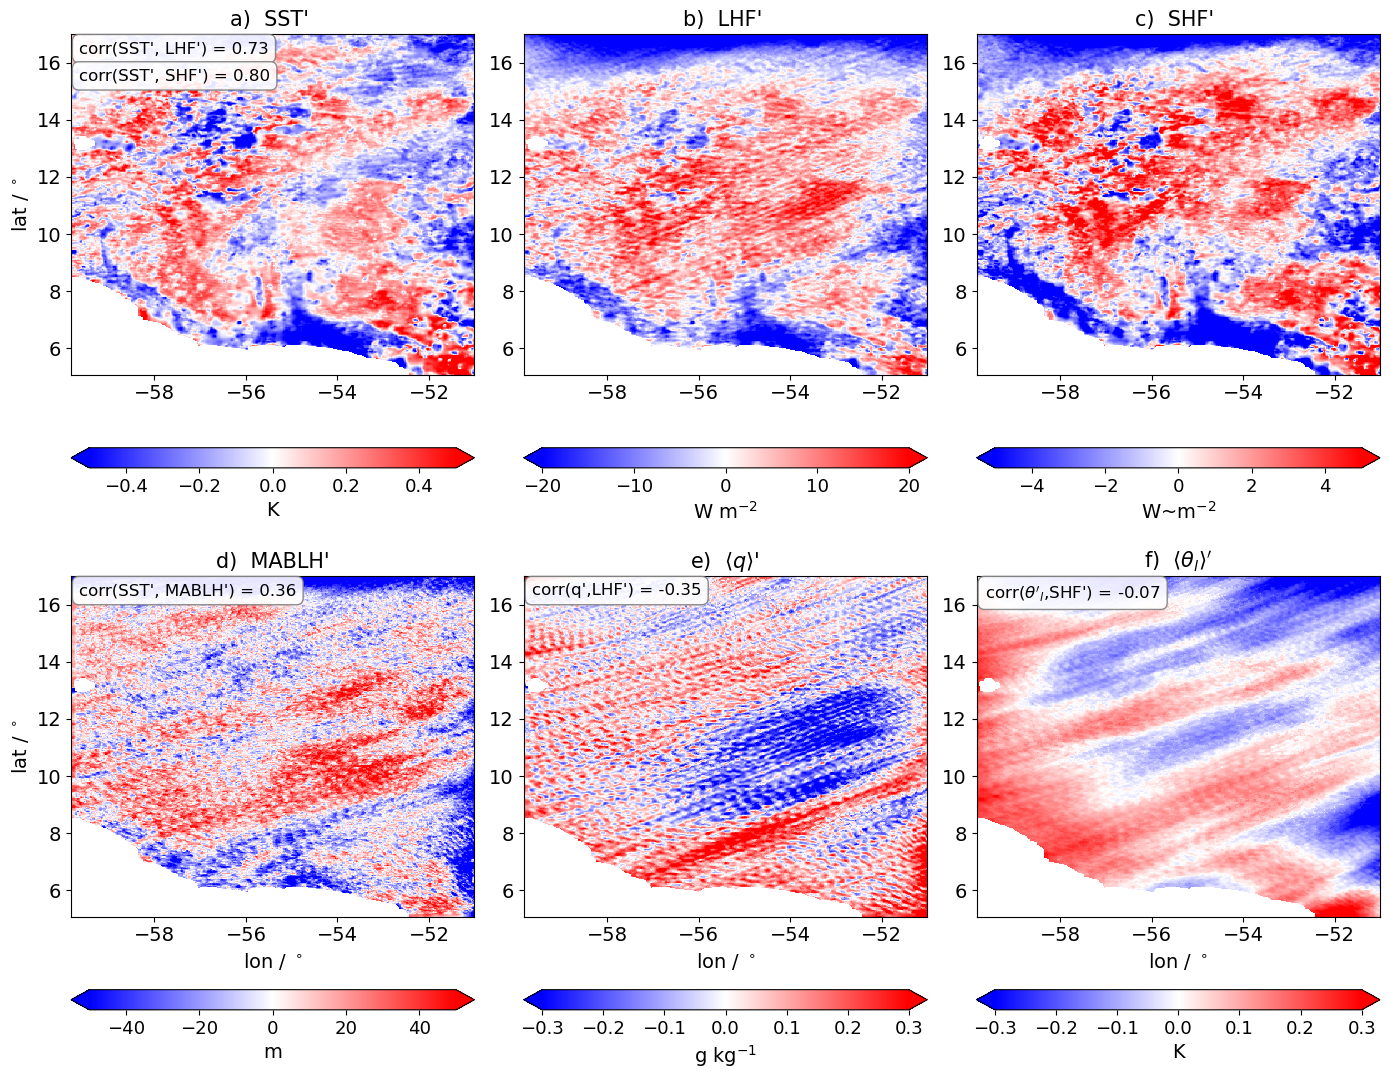

In [12]:

fig, ax = plt.subplots(2, 3, figsize=(14, 11))  # Updated to 2x3 layout and wider figure

#### first column

# Plot SST'
mesh_anoms_lhf = ax[0, 0].pcolormesh(lon, lat, (sst_prime[day]), cmap='bwr', vmin=-0.5, vmax=0.5)
ax[0, 0].set_title(r"a)  SST' ", fontsize=15)
ax[0, 0].set_ylabel('lat / $^\circ$', fontsize=14)
ax[0, 0].tick_params(axis='both', which='major', labelsize=14)
cbar_anoms = plt.colorbar(mesh_anoms_lhf, ax=ax[0, 0], location='bottom', extend='both', shrink=1, pad=0.15)
cbar_anoms.set_label(r'K', fontsize=14)
cbar_anoms.ax.tick_params(labelsize=13)


ax[0,0].text(0.02, 0.98, f"corr(SST', LHF') = {sst_lhf:.2f}", 
            transform=ax[0,0].transAxes, 
            fontsize=12, 
            verticalalignment="top", 
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white", 
                alpha=0.9,
                edgecolor="gray",
            ),
            color="black")
ax[0,0].text(0.02, 0.9, f"corr(SST', SHF') = {sst_shf:.2f}", 
            transform=ax[0,0].transAxes, 
            fontsize=12, 
            verticalalignment="top", 
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white", 
                alpha=0.9,
                edgecolor="gray",
            ),
            color="black")



# Plot PBLH'
mesh_anoms_shf = ax[1, 0].pcolormesh(lon, lat, (PBLH_prime[day]), cmap='bwr', vmin=-50., vmax=50.)
ax[1, 0].set_title(r"d)  MABLH'", fontsize=15)
ax[1, 0].set_ylabel('lat / $^\circ$', fontsize=14)
ax[1, 0].set_xlabel(r'lon / $^\circ$', fontsize=14)
ax[1, 0].tick_params(axis='both', which='major', labelsize=14)
cbar_anoms = plt.colorbar(mesh_anoms_shf, ax=ax[1, 0], location='bottom', extend='both', pad=0.15, shrink=1)
cbar_anoms.set_label(r'm', fontsize=14)
cbar_anoms.ax.tick_params(labelsize=13)

ax[1,0].text(0.02, 0.98, f"corr(SST', MABLH') = {sst_mablh:.2f}", 
            transform=ax[1,0].transAxes, 
            fontsize=12, 
            verticalalignment="top", 
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white", 
                alpha=0.9,
                edgecolor="gray",
            ),
            color="black")



### second column

# >>> New: Plot LHF'
mesh_anoms_lhf = ax[0, 1].pcolormesh(lon, lat, (lhf_prime[day]), cmap='bwr', vmin=-20., vmax=20.)
ax[0, 1].set_title(r"b)  LHF' ", fontsize=15)
ax[0, 1].tick_params(axis='both', which='major', labelsize=14)
cbar_anoms = plt.colorbar(mesh_anoms_lhf, ax=ax[0, 1], location='bottom', extend='both', pad=0.15, shrink=1)
cbar_anoms.set_label(r'W m$^{-2}$', fontsize=14)
cbar_anoms.ax.tick_params(labelsize=13)



# Plot QVAPOR'
mesh_sst = ax[1, 1].pcolormesh(lon, lat, (QVAPOR_prime[day])*1e3, cmap='bwr', vmin=-0.3, vmax=0.3)
ax[1, 1].set_title(r"e)  $\langle q \rangle$' ", fontsize=15)
ax[1,1].set_xlabel(r'lon / $^\circ$', fontsize=14)
ax[1, 1].tick_params(axis='both', which='major', labelsize=14)
cbar_anoms = plt.colorbar(mesh_sst, ax=ax[1, 1], location='bottom', extend='both', pad=0.15, shrink=1)
cbar_anoms.set_label(r'$\rm g~kg^{-1}$', fontsize=14)
cbar_anoms.ax.tick_params(labelsize=13)

ax[1,1].text(0.02, 0.98, f"corr(q',LHF') = {q_lhf:.2f}", 
            transform=ax[1,1].transAxes, 
            fontsize=12, 
            verticalalignment="top", 
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white", 
                alpha=0.9,
                edgecolor="gray",
            ),
            color="black")



## third column
# >>> New: Plot SHF'
mesh_anoms_shf = ax[0, 2].pcolormesh(lon, lat, (shf_prime[day]), cmap='bwr', vmin=-5., vmax=5.)
ax[0, 2].set_title(r"c)  SHF' ", fontsize=15)
# ax[0, 2].set_xlabel(r'lon [$^\circ$]', fontsize=14)
ax[0, 2].tick_params(axis='both', which='major', labelsize=14)
cbar_anoms = plt.colorbar(mesh_anoms_shf, ax=ax[0, 2], location='bottom', extend='both', pad=0.15, shrink=1)
cbar_anoms.set_label(r'W~m$^{-2}$', fontsize=14)
cbar_anoms.ax.tick_params(labelsize=13)



# Plot theta'
mesh_anoms_t2 = ax[1,2].pcolormesh(lon, lat, (theta_prime[day]), cmap='bwr', vmin=-0.3, vmax=0.3)
ax[1,2].set_title(r"f)  $\langle \theta_l \rangle'$ ", fontsize=15)
# ax[0,2].set_ylabel(r'lat [$^\circ$]', fontsize=14)
ax[1,2].set_xlabel(r'lon / $^\circ$', fontsize=14)
ax[1,2].tick_params(axis='both', which='major', labelsize=14)
cbar_anoms = plt.colorbar(mesh_anoms_t2, ax=ax[1,2], location='bottom', extend='both', pad=0.15, shrink=1)
cbar_anoms.set_label('K', fontsize=14)
cbar_anoms.ax.tick_params(labelsize=13)


ax[1,2].text(0.02, 0.98, fr"corr($\theta'_l$,SHF') = {th_shf:.2f}", 
            transform=ax[1,2].transAxes, 
            fontsize=12, 
            verticalalignment="top", 
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white", 
                alpha=0.9,
                edgecolor="gray",
            ),
            color="black")


plt.tight_layout()



## Supplementary figure S1: SST' and LHF' , varying sigma

In [20]:
scales = np.linspace(20, 200, 4).astype(int)
scales_km = list(4*3*scales)
scales_km = [str(i)+' km' for i in scales_km]

import pandas as pd
indices = ['SST', 'LHF']
df_primes_sstLhf= pd.DataFrame(data=None, index = indices, columns=scales_km)
df_primes_sstLhf

,240 km,960 km,1680 km,2400 km
SST,NaN,NaN,NaN,NaN
LHF,NaN,NaN,NaN,NaN


In [ ]:
for i in range(scales.shape[0]):
    sst_prime     = np.zeros_like(sst_ff)
    lhf_prime     = np.zeros_like(lhf_bulk)
    
    
    for t in range(0,sst_ff.shape[0]):
        sst_sm = functions.nan_gaussian_filter(sst_ff[t], scales[i])
        X_prime = sst_ff[t] - sst_sm
        sst_prime[t] = functions.nan_gaussian_filter(X_prime,0)
        
        lhf_bulk_sm = functions.nan_gaussian_filter(lhf_bulk[t], scales[i])
        X_prime = lhf_bulk[t] - lhf_bulk_sm
        lhf_prime[t] = functions.nan_gaussian_filter(X_prime,0)
    
    df_primes_sstLhf.iloc[0,df_primes_sstLhf.columns.get_loc(scales_km[i])]        = sst_prime
    df_primes_sstLhf.iloc[1,df_primes_sstLhf.columns.get_loc(scales_km[i])]      = lhf_prime

/venus/tesi_ale/plots_QJRMS/figS01_rev.png


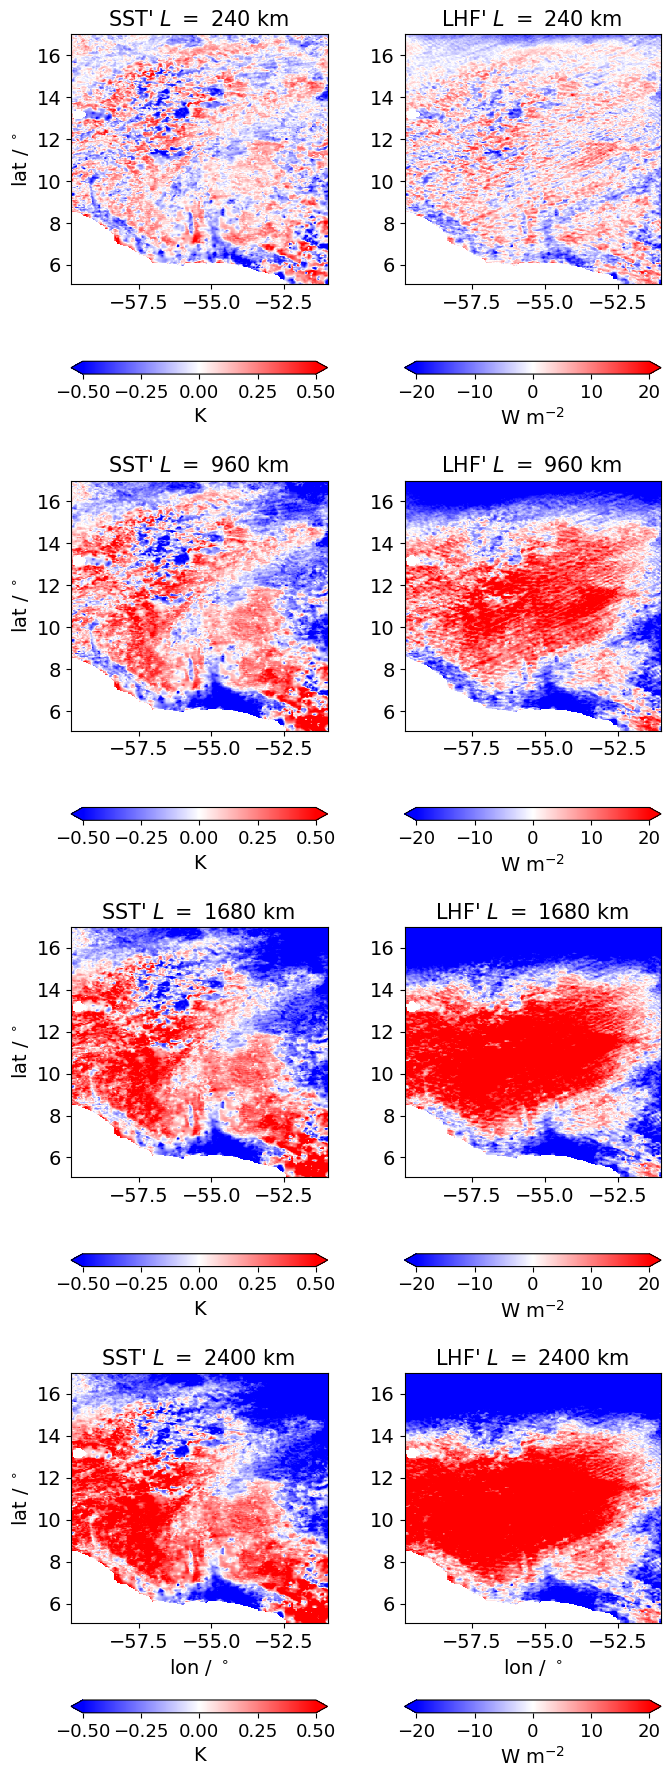

In [22]:
fig, ax = plt.subplots(4,2, figsize=(7,18))
day = int(0)

for i, x in enumerate(scales_km): 

    # Plot SST'
    mesh_anoms_sst = ax[i, 0].pcolormesh(lon, lat, (df_primes_sstLhf.loc['SST', x][day]), cmap='bwr', vmin=-0.5, vmax=0.5)
    ax[i, 0].set_title(r"SST' $L~=$"+f" {x} ", fontsize=15)
    ax[i, 0].set_ylabel('lat / $^\circ$', fontsize=14)
    ax[i, 0].tick_params(axis='both', which='major', labelsize=14)

    cbar_anoms = plt.colorbar(mesh_anoms_sst, ax=ax[i, 0], location='bottom', extend='both', shrink=1, pad=0.2)
    cbar_anoms.set_label(r'K', fontsize=14)
    cbar_anoms.ax.tick_params(labelsize=13)
    
    # >>> New: Plot LHF'
    mesh_anoms_lhf = ax[i, 1].pcolormesh(lon, lat, (df_primes_sstLhf.loc['LHF', x][day]), cmap='bwr', vmin=-20., vmax=20.)
    ax[i, 1].set_title(r"LHF' $L~=$"+f" {x} ", fontsize=15)
    ax[i, 1].tick_params(axis='both', which='major', labelsize=14)

    cbar_anoms = plt.colorbar(mesh_anoms_lhf, ax=ax[i, 1], location='bottom', extend='both', pad=0.2, shrink=1)
    cbar_anoms.set_label(r'W m$^{-2}$', fontsize=14)
    cbar_anoms.ax.tick_params(labelsize=13)

ax[-1, 0].set_xlabel('lon / $^\circ$', fontsize=14)
ax[-1, 1].set_xlabel('lon / $^\circ$', fontsize=14)






plt.tight_layout()



## Fig. 5 : coupling coefficients $\psi$-SST vs sigma

In [25]:
import pandas as pd

scales = np.concatenate((np.arange(5, 125, 20), np.arange(125, 250, 50)))
scales_km = list(3*scales)
scales_km = [str(i)+' km' for i in scales_km]


df_index = ['fit', 'lin_corr', 'p_val', 'p_val_cannelli', 'sigmas']
fit_q_sst     = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_lhf_sst   = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_T_sst     = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_mablh_sst = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_U_sst     = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_shf_sst   = pd.DataFrame(data=None, index = df_index, columns=scales_km)

In [26]:
print(scales)
print(scales_km)

[  5  25  45  65  85 105 125 175 225]
['15 km', '75 km', '135 km', '195 km', '255 km', '315 km', '375 km', '525 km', '675 km']


#### with gaussian filter

In [ ]:
for i in range(scales.shape[0]):
    sst_prime     = np.zeros_like(sst_ff)
    ta_prime      = np.zeros_like(ta_ff)
    qa_prime      = np.zeros_like(qa_ff)
    U_prime       = np.zeros_like(U_ff)
    lhf_prime = np.zeros_like(lhf_bulk)
    shf_prime = np.zeros_like(shf_bulk)
    mablh_prime = np.zeros_like(PBLH_day)
    
    for t in range(0,sst_ff.shape[0]):
        sst_sm = functions.nan_gaussian_filter(sst_ff[t], scales[i])
        X_prime = sst_ff[t] - sst_sm
        sst_prime[t] = functions.nan_gaussian_filter(X_prime,0)

        mablh_sm = functions.nan_gaussian_filter(PBLH_day[t], scales[i])
        X_prime = PBLH_day[t] - mablh_sm
        mablh_prime[t] = functions.nan_gaussian_filter(X_prime,0)

        ta_sm = functions.nan_gaussian_filter(ta_ff[t], scales[i])
        X_prime = ta_ff[t] - ta_sm
        ta_prime[t] = functions.nan_gaussian_filter(X_prime,0)

        qa_sm = functions.nan_gaussian_filter(qa_ff[t], scales[i])
        X_prime = qa_ff[t] - qa_sm
        qa_prime[t] = functions.nan_gaussian_filter(X_prime,0)

        U_sm = functions.nan_gaussian_filter(U_ff[t], scales[i])
        X_prime = U_ff[t] - U_sm
        U_prime[t] = functions.nan_gaussian_filter(X_prime,0)
        
        lhf_bulk_sm = functions.nan_gaussian_filter(lhf_bulk[t], scales[i])
        X_prime = lhf_bulk[t] - lhf_bulk_sm
        lhf_prime[t] = functions.nan_gaussian_filter(X_prime,0)
        
        shf_bulk_sm = functions.nan_gaussian_filter(shf_bulk[t], scales[i])
        X_prime = shf_bulk[t] - shf_bulk_sm
        shf_prime[t] = functions.nan_gaussian_filter(X_prime,0)

    sst_q     = functions.slopes_r_p_mix(sst_prime, qa_prime, nt, nskip, ls = True)   
    sst_shf   = functions.slopes_r_p_mix(sst_prime, shf_prime, nt, nskip, ls = True)  
    sst_ta    = functions.slopes_r_p_mix(sst_prime, ta_prime , nt, nskip, ls = True)
    sst_mablh = functions.slopes_r_p_mix(sst_prime, mablh_prime, nt, nskip, ls = True)  
    sst_lhf   = functions.slopes_r_p_mix(sst_prime, lhf_prime, nt, nskip, ls = True) 
    sst_U     = functions.slopes_r_p_mix(sst_prime, U_prime, nt, nskip, ls = True)


    fit_q_sst.iloc[:,fit_q_sst.columns.get_loc(scales_km[i])]          = sst_q               
    fit_shf_sst.iloc[:,fit_shf_sst.columns.get_loc(scales_km[i])]      = sst_shf              
    
    fit_lhf_sst.iloc[:,fit_lhf_sst.columns.get_loc(scales_km[i])]      = sst_lhf               
    fit_T_sst.iloc[:,fit_T_sst.columns.get_loc(scales_km[i])]          = sst_ta             
    
    fit_U_sst.iloc[:,fit_U_sst.columns.get_loc(scales_km[i])]          = sst_U               
    fit_mablh_sst.iloc[:,fit_mablh_sst.columns.get_loc(scales_km[i])]  = sst_mablh             
    
    print(f'step {i} done')

step 0 done
step 1 done
step 2 done
step 3 done
step 4 done
step 5 done
step 6 done
step 7 done
step 8 done


In [28]:
# Slopes
slopes_q_sst     = [fit_q_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_lhf_sst   = [fit_lhf_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_T_sst     = [fit_T_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_mablh_sst = [fit_mablh_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_U_sst     = [fit_U_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_shf_sst   = [fit_shf_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
# slopes_all = [slopes_q_sst, slopes_lhf_sst, slopes_T_sst, slopes_mablh_sst, slopes_U_sst, slopes_shf_sst]

# Sigmas
sigma_q_sst     = [fit_q_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_lhf_sst   = [fit_lhf_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_T_sst     = [fit_T_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_mablh_sst = [fit_mablh_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_U_sst     = [fit_U_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_shf_sst   = [fit_shf_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigmas_all      = [sigma_q_sst, sigma_lhf_sst, sigma_T_sst, sigma_mablh_sst, sigma_U_sst, sigma_shf_sst]

/venus/tesi_ale/plots_QJRMS/coupling_SST_scales_rev.pdf


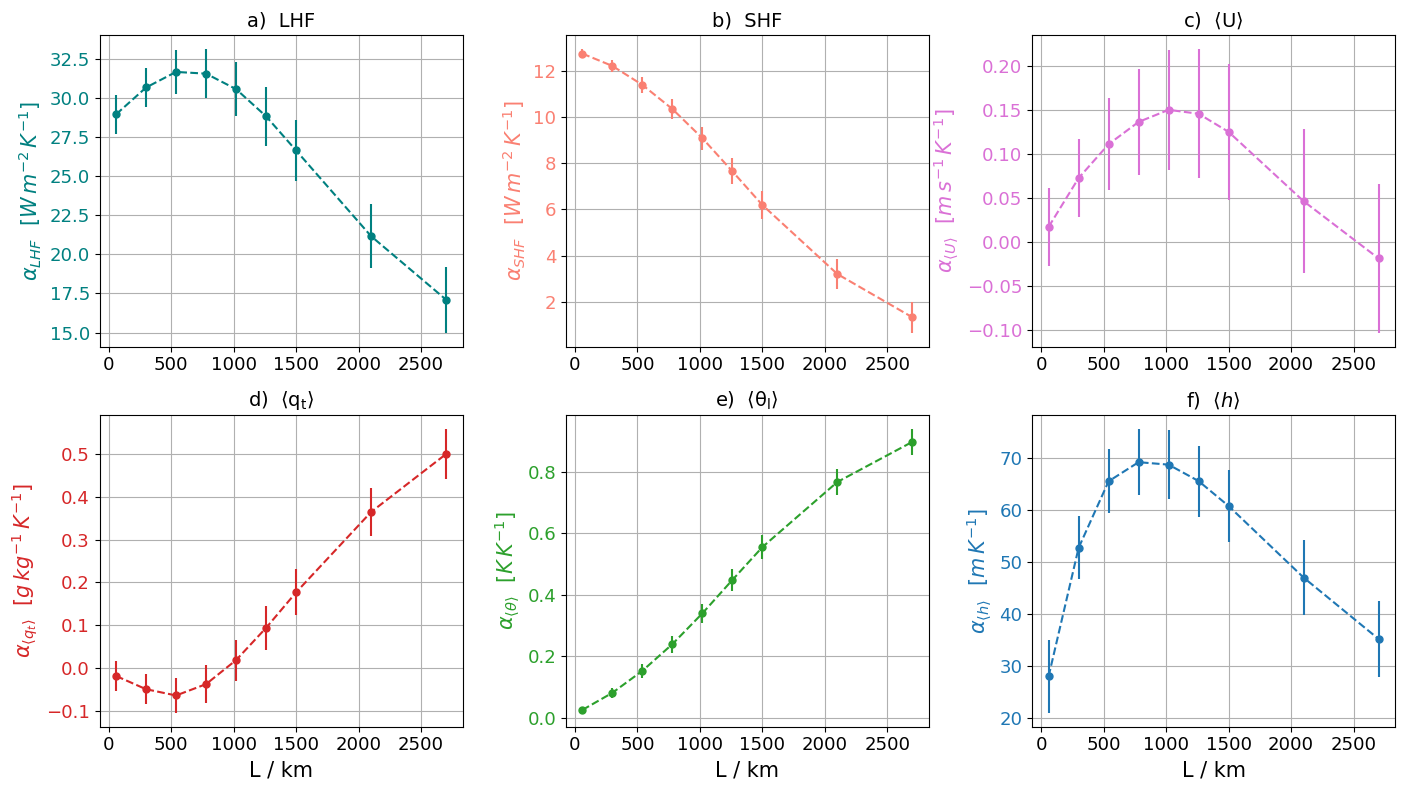

In [30]:
## REVIEWED PLOT

import matplotlib.pyplot as plt

# Group data
slopes = [slopes_lhf_sst, slopes_shf_sst, slopes_U_sst,\
          [x*1e3 for x in slopes_q_sst], slopes_T_sst, slopes_mablh_sst]

sigmas = [sigma_lhf_sst, sigma_shf_sst,  sigma_U_sst,\
         [x*1e3 for x in sigma_q_sst] ,sigma_T_sst, sigma_mablh_sst]


titles = ['a)  LHF',             'b)  SHF',                         r"c)  $\rm \langle U \rangle$",\
          r"d)  $\rm \langle q_t \rangle$" , r"e)  $\rm \langle \theta_l \rangle$",     r'f)  $\langle h \rangle$']
colors = ['teal', 'salmon', 'orchid',\
          'tab:red', 'tab:green', 'tab:blue']

ylabels_units = [
    r"$\alpha_{LHF}$  [$W\,m^{-2}\,K^{-1}$]", r"$\alpha_{SHF}$  [$W\,m^{-2}\,K^{-1}$]", r"$\alpha_{\langle U \rangle}$  [$m\,s^{-1}\,K^{-1}$]", \
    r"$\alpha_{\langle q_t \rangle}$  [$g\,kg^{-1}\,K^{-1}$]", r"$\alpha_{\langle \theta \rangle}$  [$K\,K^{-1}$]",  r"$\alpha_{\langle h \rangle}$  [$m\,K^{-1}$]"   
]

# Create 2x3 subplots
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i in range(6):
    ax = axs[i]
    color = colors[i]

    # Plot slopes with error bars
    ax.errorbar(
        3 * 4 * scales,     ## the scale with physical meaning for the Gaussian filter is 4*
        slopes[i],
        yerr=sigmas[i],
        fmt='o',
        color=color,
        markersize=5,
        ecolor=color,
        linestyle='--',
        label='sensitivity'
    )
    ax.set_ylabel(ylabels_units[i], fontsize=15, color=color)
    ax.tick_params(axis='y', labelcolor=color)
    if i>2:
        ax.set_xlabel('L / km', fontsize=15)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_title(f"{titles[i]}", fontsize=14)
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()

fig.tight_layout()


#### with the boxcar filter

In [69]:
import pandas as pd

scales = np.concatenate((np.arange(5, 125, 20), np.arange(125, 250, 50)))
scales_km = list(3*scales)
scales_km = [str(i)+' km' for i in scales_km]


df_index = ['fit', 'lin_corr', 'p_val', 'p_val_cannelli', 'sigmas']
fit_q_sst     = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_lhf_sst   = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_T_sst     = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_mablh_sst = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_U_sst     = pd.DataFrame(data=None, index = df_index, columns=scales_km)
fit_shf_sst   = pd.DataFrame(data=None, index = df_index, columns=scales_km)

In [ ]:
for i in range(scales.shape[0]):
    sst_prime     = np.zeros_like(sst_ff)
    ta_prime      = np.zeros_like(ta_ff)
    qa_prime      = np.zeros_like(qa_ff)
    U_prime       = np.zeros_like(U_ff)
    lhf_prime = np.zeros_like(lhf_bulk)
    shf_prime = np.zeros_like(shf_bulk)
    mablh_prime = np.zeros_like(PBLH_day)
    
    ## for a fair conversion from gaussian to box
    filter_width = 4*scales[i]
    
    for t in range(0,sst_ff.shape[0]):
        sst_sm = functions.boxcar_filter(sst_ff[t], filter_width)
        X_prime = sst_ff[t] - sst_sm
        sst_prime[t] = functions.boxcar_filter(X_prime,0)

        mablh_sm = functions.boxcar_filter(PBLH_day[t], filter_width)
        X_prime = PBLH_day[t] - mablh_sm
        mablh_prime[t] = functions.boxcar_filter(X_prime,0)

        ta_sm = functions.boxcar_filter(ta_ff[t], filter_width)
        X_prime = ta_ff[t] - ta_sm
        ta_prime[t] = functions.boxcar_filter(X_prime,0)

        qa_sm = functions.boxcar_filter(qa_ff[t], filter_width)
        X_prime = qa_ff[t] - qa_sm
        qa_prime[t] = functions.boxcar_filter(X_prime,0)

        U_sm = functions.boxcar_filter(U_ff[t], filter_width)
        X_prime = U_ff[t] - U_sm
        U_prime[t] = functions.boxcar_filter(X_prime,0)
        
        lhf_bulk_sm = functions.boxcar_filter(lhf_bulk[t], filter_width)
        X_prime = lhf_bulk[t] - lhf_bulk_sm
        lhf_prime[t] = functions.boxcar_filter(X_prime,0)
        
        shf_bulk_sm = functions.boxcar_filter(shf_bulk[t], filter_width)
        X_prime = shf_bulk[t] - shf_bulk_sm
        shf_prime[t] = functions.boxcar_filter(X_prime,0)

    sst_q     = functions.slopes_r_p_mix(sst_prime, qa_prime, nt, nskip, ls = True)   
    sst_shf   = functions.slopes_r_p_mix(sst_prime, shf_prime, nt, nskip, ls = True)  
    sst_ta    = functions.slopes_r_p_mix(sst_prime, ta_prime , nt, nskip, ls = True)
    sst_mablh = functions.slopes_r_p_mix(sst_prime, mablh_prime, nt, nskip, ls = True)  
    sst_lhf   = functions.slopes_r_p_mix(sst_prime, lhf_prime, nt, nskip, ls = True) 
    sst_U     = functions.slopes_r_p_mix(sst_prime, U_prime, nt, nskip, ls = True)


    fit_q_sst.iloc[:,fit_q_sst.columns.get_loc(scales_km[i])]          = sst_q               
    fit_shf_sst.iloc[:,fit_shf_sst.columns.get_loc(scales_km[i])]      = sst_shf              
    
    fit_lhf_sst.iloc[:,fit_lhf_sst.columns.get_loc(scales_km[i])]      = sst_lhf               
    fit_T_sst.iloc[:,fit_T_sst.columns.get_loc(scales_km[i])]          = sst_ta             
    
    fit_U_sst.iloc[:,fit_U_sst.columns.get_loc(scales_km[i])]          = sst_U               
    fit_mablh_sst.iloc[:,fit_mablh_sst.columns.get_loc(scales_km[i])]  = sst_mablh             
    
    print(f'step {i} done')

step 0 done
step 1 done
step 2 done
step 3 done
step 4 done
step 5 done
step 6 done
step 7 done
step 8 done


In [2]:
# Slopes
slopes_q_sst     = [fit_q_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_lhf_sst   = [fit_lhf_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_T_sst     = [fit_T_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_mablh_sst = [fit_mablh_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_U_sst     = [fit_U_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
slopes_shf_sst   = [fit_shf_sst.loc['fit', scales_km[i]].slope for i in range(len(scales))]
# slopes_all = [slopes_q_sst, slopes_lhf_sst, slopes_T_sst, slopes_mablh_sst, slopes_U_sst, slopes_shf_sst]

# Sigmas
sigma_q_sst     = [fit_q_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_lhf_sst   = [fit_lhf_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_T_sst     = [fit_T_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_mablh_sst = [fit_mablh_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_U_sst     = [fit_U_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigma_shf_sst   = [fit_shf_sst.loc['sigmas', scales_km[i]][0] for i in range(len(scales))]
sigmas_all      = [sigma_q_sst, sigma_lhf_sst, sigma_T_sst, sigma_mablh_sst, sigma_U_sst, sigma_shf_sst]

NameError: name 'scales' is not defined

In [3]:
import matplotlib.pyplot as plt

# Group data
slopes = [slopes_lhf_sst, slopes_shf_sst, slopes_U_sst,\
          [x*1e3 for x in slopes_q_sst], slopes_T_sst, slopes_mablh_sst]

sigmas = [sigma_lhf_sst, sigma_shf_sst,  sigma_U_sst,\
         [x*1e3 for x in sigma_q_sst] ,sigma_T_sst, sigma_mablh_sst]


titles = ['a)  LHF',             'b)  SHF',                         r"c)  $\rm \langle U \rangle$",\
          r"d)  $\rm \langle q_t \rangle$" , r"e)  $\rm \langle \theta \rangle$",     r'f)  $\langle h \rangle$']
colors = ['teal', 'salmon', 'orchid',\
          'tab:red', 'tab:green', 'tab:blue']

ylabels_units = [
    r"$\alpha_{LHF}$  [$W\,m^{-2}\,K^{-1}$]", r"$\alpha_{SHF}$  [$W\,m^{-2}\,K^{-1}$]", r"$\alpha_{\langle U \rangle}$  [$m\,s^{-1}\,K^{-1}$]", \
    r"$\alpha_{\langle q_t \rangle}$  [$g\,kg^{-1}\,K^{-1}$]", r"$\alpha_{\langle \theta \rangle}$  [$K\,K^{-1}$]",  r"$\alpha_{\langle h \rangle}$  [$m\,K^{-1}$]"   
]

# Create 2x3 subplots
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Boxcar filter applied")
axs = axs.flatten()

for i in range(6):
    ax = axs[i]
    color = colors[i]

    # Plot slopes with error bars
    ax.errorbar(
        4 * 3 * scales,
        slopes[i],
        yerr=sigmas[i],
        fmt='o',
        color=color,
        markersize=5,
        ecolor=color,
        linestyle='--',
        label='sensitivity'
    )
    ax.set_ylabel(ylabels_units[i], fontsize=15, color=color)
    ax.tick_params(axis='y', labelcolor=color)
    
    if i<=2:
        ax.set_xticks([800, 1600, 2400]) 
        ax.set_xticklabels(['', '', ''])

    if i>2:
        ax.set_xlabel('Filter size / km', fontsize=15)
        
        # ax2 = ax.twiny()
        # ax2.set_xlim(ax.get_xlim())
        # ax2.set_xticks([200, 400, 600])  #(3*scales)
        # ax2.set_xticklabels(['400', '800', '1200'])  #([2*3*sc for sc in scales])
        # ax2.xaxis.set_ticks_position('bottom')
        # ax2.xaxis.set_label_position('bottom')
        # ax2.spines['bottom'].set_position(('outward', 20))
        # ax2.spines['top'].set_visible(False)
        
        # ax2.set_xlabel("Filter size / km", fontsize=14)
        # ax2.tick_params(axis='x', labelsize=12)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
        
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_title(f"{titles[i]}", fontsize=14)
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()

for x in axs.flatten():
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

fig.tight_layout()

base_path = '/venus/tesi_ale/plots_QJRMS/'
filename = base_path + 'couplingCoeff_SST_scales_boxcar.png'
print(filename)
# plt.savefig(filename, bbox_inches='tight', dpi=300)


NameError: name 'slopes_lhf_sst' is not defined

## Initial Fig. 7 : upscaling terms

In [16]:
sigma_sub = 0 # *3km = 60 km

import pandas as pd

scales = np.arange(5, 250, 40)
scales_km = list(3*scales)
scales_km = [str(i)+' km' for i in scales_km]
dims = sst_ff.shape

df = pd.DataFrame(data=None, index = ['beta_covar_U_Dq', 'beta_Ubar_qprime_bar', 'beta_Uprime_qbar_bar', 'all_small_scale', 'beta_Ubar_qbar_bar', 'lhf_bar'], columns=scales_km)

In [ ]:
for i,sigma in enumerate(scales):
    
    lhf_bulk_bar = np.zeros(dims)

    qa_bar = np.zeros(qa_ff.shape); 
    U_bar = np.zeros(U_ff.shape) 
    qs_bar = np.zeros(qs_sea.shape);
 
    qa_prime = np.zeros(qa_ff.shape); 
    U_prime = np.zeros(U_ff.shape) 
    qs_prime = np.zeros(qs_sea.shape);

    covar_U_Dq = np.zeros(dims)                                            # \o{U'Dq'}
    Ubar_qprime_bar, Uprime_qbar_bar = np.zeros(dims), np.zeros(dims)      # U'\o{Dq} , \o{U}Dq'
    Ubar_qbar_bar = np.zeros(dims)                                         # \o{ \o{U} \o{Dq} }
    
    for t in range(0,dims[0]):
    
        qa_bar[t] = functions.nan_gaussian_filter(qa_ff[t],sigma)
        X_prime = qa_ff[t] - qa_bar[t]
        qa_prime[t] = functions.nan_gaussian_filter(X_prime,sigma_sub)
        
        U_bar[t] = functions.nan_gaussian_filter(U_ff[t],sigma)
        X_prime = U_ff[t] - U_bar[t]
        U_prime[t] = functions.nan_gaussian_filter(X_prime,sigma_sub)
        
        qs_bar[t] = functions.nan_gaussian_filter(qs_sea[t],sigma)
        X_prime = qs_sea[t] - qs_bar[t]
        qs_prime[t] = functions.nan_gaussian_filter(X_prime,sigma_sub)

        lhf_bulk_bar[t] = functions.nan_gaussian_filter(lhf_bulk[t],sigma)
        
        
        covar_U_Dq[t] = local_covariance(U_prime[t],(qs_prime[t]-qa_prime[t]),sigma)

        Ubar_qprime_bar[t] = local_covariance(U_bar[t],   (qs_prime[t]- qa_prime[t]),sigma)
        Uprime_qbar_bar[t] = local_covariance(U_prime[t], (qs_bar[t]  - qa_bar[t])  ,sigma)
        Ubar_qbar_bar[t]   = local_covariance(U_bar[t],   (qs_bar[t]  - qa_bar[t])  ,sigma)
    
    df.loc['beta_covar_U_Dq', str(3*sigma)+' km']      = (beta*covar_U_Dq)  #.flatten()
    df.loc['beta_Ubar_qprime_bar', str(3*sigma)+' km'] = (beta*Ubar_qprime_bar)  #.flatten()
    df.loc['beta_Uprime_qbar_bar', str(3*sigma)+' km'] = (beta*Uprime_qbar_bar)  #.flatten()
    df.loc['all_small_scale', str(3*sigma)+' km']      = (beta*Ubar_qprime_bar + beta*Uprime_qbar_bar)  #.flatten()
    
    df.loc['beta_Ubar_qbar_bar', str(3*sigma)+' km']   = (beta*Ubar_qbar_bar)  #.flatten()
    df.loc['lhf_bar', str(3*sigma)+' km']              = lhf_bulk_bar  #.flatten()
    print(f"step {i} done")

step 0 done
step 1 done
step 2 done
step 3 done
step 4 done
step 5 done
step 6 done


/venus/tesi_ale/plots_forced_EU/upscaling_terms.pdf


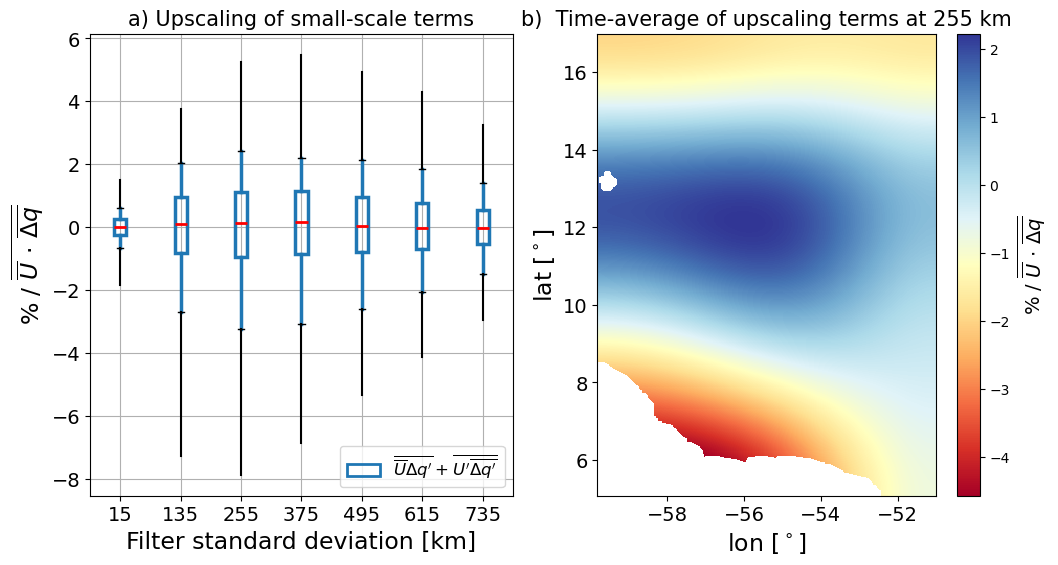

In [37]:
def boxplot_local(ax, df, beta_vars, var_names, colors, scales_km, title, axlabs):
    """
    Plots grouped boxplots for each of the beta_* variables across different filter scales,
    with extended light-gray lines showing the 0–1st and 99–100th percentile ranges.
    """
    import numpy as np
    import matplotlib.patches as mpatches

    n_groups = len(scales_km)
    n_vars = len(beta_vars)

    box_data = [[] for _ in range(n_vars)]
    whisker_lines = [[] for _ in range(n_vars)]  # to store min/max percentile extensions

    for i, var in enumerate(beta_vars):
        for col in df.columns:
            arr = 100 * df.loc[var, col] / df.loc['beta_Ubar_qbar_bar', col]
            arr = arr[~np.isnan(arr)]

            # Compute full-range percentiles
            p0, p1 = np.nanpercentile(arr, [0.5, 10])
            p99, p100 = np.nanpercentile(arr, [90, 99.5])
            whisker_lines[i].append(((p0, p1), (p99, p100)))

            # Keep only trimmed values for boxplot
            trimmed = arr[(arr >= p1) & (arr <= p99)]
            box_data[i].append(trimmed.flatten())

    # Plot grouped boxplots
    positions = []
    width = 0.2
    for i in range(n_vars):
        positions.append(np.arange(n_groups) + (i - 1) * width)

    for i in range(n_vars):
        bp = ax.boxplot(
            box_data[i], positions=positions[i], widths=width,
            patch_artist=True, showmeans=False, whis=[0, 100],
            boxprops=dict(color=colors[i], facecolor='none', linewidth=2.5), 
            medianprops=dict(linewidth=2, color='red'),
            whiskerprops=dict(color=colors[i], linewidth=2.5), 
            flierprops=dict(marker='o', color=colors[i], alpha=0.0)  # hide flier markers
        )

        # Plot light gray whisker lines for outlier range
        for j, ((p0, p1), (p99, p100)) in enumerate(whisker_lines[i]):
            x = positions[i][j]
            # Low end (0–1st percentile)
            ax.plot([x, x], [p0, p1], color='black', linewidth=1.5)#, zorder=1)
            # High end (99–100th percentile)
            ax.plot([x, x], [p99, p100], color='black', linewidth=1.5)#, zorder=1)

    # Axis settings
    group_centers = np.mean(np.array(positions), axis=0)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(scales_km, fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(axlabs[0], fontsize=17)
    ax.set_ylabel(axlabs[1], fontsize=17)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid()

    # Custom legend
    legend_handles = [
        mpatches.Patch(edgecolor=colors[i], facecolor='none', linewidth=2, label=var_names[i])
        for i in range(len(var_names))
    ]
    ax.legend(handles=legend_handles, loc='best', fontsize=12, frameon=True)


# Example usage:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# fig.suptitle(f"depth integrated = {str(depth_integrated)}")
# ['beta_covar_U_Dq', 'beta_Ubar_qprime_bar', 'beta_Uprime_qbar_bar',]
# [r"$\overline{U'\Delta q'}$", r"$\overline{\overline{U} \Delta q'}$", r"$\overline{U'\overline{\Delta q'}}$"]
# ['tab:blue', 'tab:orange', 'tab:green']
boxplot_local(
    ax[0], df, beta_vars = ['all_small_scale'] ,\
    var_names = [r"$\overline{\overline{U} \Delta q'} + \overline{U'\overline{\Delta q'}}$"],\
    colors = ['tab:blue'], scales_km=[str(3*j) for j in scales],\
    title=r"a) Upscaling of small-scale terms",
    axlabs=['Filter standard deviation [km]', r"% / $\overline{\overline{U} \,\cdot\, \overline{\Delta q}}$"]
)


small_scale_time_avg = np.nanmean( df.loc['all_small_scale', '255 km'], axis=0)
bar_time_avg = np.nanmean( df.loc['beta_Ubar_qbar_bar', '255 km'], axis=0)

msh_p = ax[1].pcolormesh(lon, lat, 100*small_scale_time_avg/bar_time_avg, cmap='RdYlBu')#, vmin=-2, vmax=2)
cbar = plt.colorbar(msh_p, ax=ax[1]) #,  extend='min')
cbar.set_label(r"% / $\overline{\overline{U} \,\cdot\, \overline{\Delta q}}$ ", fontsize=14)
ax[1].set_title("b)  Time-average of upscaling terms at 255 km", fontsize=15)
# ax[0].set_xticklabels(fontsize=14)
ax[1].set_xlabel(r'lon [$^\circ$]', fontsize=17)
ax[1].set_ylabel(r'lat [$^\circ$]', fontsize=17)
ax[1].tick_params(axis='both', which='major', labelsize=14)

# plt.tight_layout()

base_path = '/venus/tesi_ale/plots_forced_EU/'
filename = base_path + 'upscaling_terms.pdf'
print(filename)
# plt.savefig(filename)

### reply to first round of reviews: 
plot $$LHF^c = \frac{\overline{LHF} - \beta  \overline{ \overline{U}~(q_s(\overline{SST}) - \overline{q_a}) } }{ \beta \overline{ \overline{U}~(q_s(\overline{SST}) - \overline{q_a}) } }$$

In [23]:
rho_a = 1.2 # kg/m3
Lv = 2.5e6-ta_ff*(2.5-2.2)*1e4 # J/kg
Ch = 1.1e-3 # representative value of the exchange coefficient (it has a weak dependence on the wind speed)
beta = rho_a*Lv*Ch
cpd = 1004.67
gamma = rho_a*Ch*cpd


###################  reference formulation  #################

lhf_field = beta*U_ff*(qs_sea-qa_ff)
shf_field = gamma*U_ff*(sst_ff - ta_ff)


In [24]:
sigma_sub = 0 # *3km = 60 km

import pandas as pd

scales = np.arange(5, 255, 25)
scales_km = list(3*scales)
scales_km = [str(i)+' km' for i in scales_km]
dims = sst_ff.shape

df_review = pd.DataFrame(data=None, index = ['lhf_c', 'lhf_c_bar', 'lhf_bar', 'lhf - lhf_c / lhf_c', 'lhf_* / lhf_c_bar'], columns=scales_km)

In [ ]:
for i,sigma in enumerate(scales):
    
    lhf_bar = np.zeros(dims)

    qa_bar  = np.zeros(qa_ff.shape); 
    U_bar   = np.zeros(U_ff.shape) 
    sst_bar = np.zeros(sst_ff.shape) 
    lhf_c   = np.zeros(lhf_field.shape)
    lhf_c_bar = np.zeros(lhf_field.shape)
    
    for t in range(0,dims[0]):
        qa_bar[t] = functions.nan_gaussian_filter(qa_ff[t],sigma)
        
        U_bar[t] = functions.nan_gaussian_filter(U_ff[t],sigma)
        
        sst_bar[t] = functions.nan_gaussian_filter(sst_ff[t],sigma)

        lhf_c[t]   = beta[t]*U_bar[t]*( q_sat(sst_bar[t]-273.15, p0) - qa_bar[t])
        lhf_c_bar[t]   = functions.nan_gaussian_filter(lhf_c[t],sigma)

        lhf_bar[t] = functions.nan_gaussian_filter(lhf_field[t],sigma)
        
    df_review.loc['lhf_c', str(3*sigma)+' km']   = lhf_c 
    df_review.loc['lhf_c_bar', str(3*sigma)+' km']   = lhf_c_bar
    df_review.loc['lhf_bar', str(3*sigma)+' km']     = lhf_bar
    df_review.loc['lhf - lhf_c / lhf_c', str(3*sigma)+' km']  = (lhf_field - lhf_c)/lhf_c
    df_review.loc['lhf_* / lhf_c_bar', str(3*sigma)+' km']  = (lhf_bar - lhf_c_bar)/lhf_c_bar
    print(f"step {i} done")

step 0 done
step 1 done
step 2 done
step 3 done
step 4 done
step 5 done
step 6 done
step 7 done
step 8 done
step 9 done


/venus/tesi_ale/plots_QJRMS/new_upscaling_LHF_rev.png


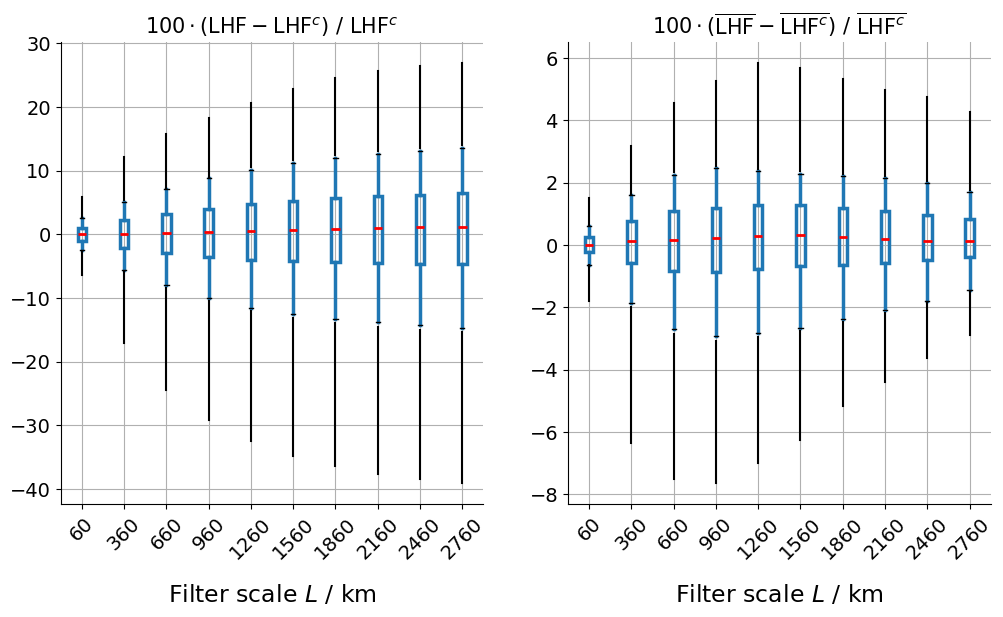

In [29]:
def boxplot_local(ax, df, beta_vars, var_names, colors, scales_km, title, axlabs):
    """
    Plots grouped boxplots for each of the beta_* variables across different filter scales,
    with extended light-gray lines showing the 0–1st and 99–100th percentile ranges.
    """
    import numpy as np
    import matplotlib.patches as mpatches

    n_groups = len(scales_km)
    n_vars = len(beta_vars)

    box_data = [[] for _ in range(n_vars)]
    whisker_lines = [[] for _ in range(n_vars)]  # to store min/max percentile extensions

    for i, var in enumerate(beta_vars):
        for col in df.columns:
            arr = 100 * df.loc[var, col]
            arr = arr[~np.isnan(arr)]

            # Compute full-range percentiles
            p0, p1 = np.nanpercentile(arr, [0.5, 10])
            p99, p100 = np.nanpercentile(arr, [90, 99.5])
            whisker_lines[i].append(((p0, p1), (p99, p100)))

            # Keep only trimmed values for boxplot
            trimmed = arr[(arr >= p1) & (arr <= p99)]
            box_data[i].append(trimmed.flatten())

    # Plot grouped boxplots
    positions = []
    width = 0.2
    for i in range(n_vars):
        positions.append(np.arange(n_groups) + (i - 1) * width)

    for i in range(n_vars):
        bp = ax.boxplot(
            box_data[i], positions=positions[i], widths=width,
            patch_artist=True, showmeans=False, whis=[1, 99],
            boxprops=dict(color=colors[i], facecolor='none', linewidth=2.5), 
            medianprops=dict(linewidth=2, color='red'),
            whiskerprops=dict(color=colors[i], linewidth=2.5), 
            flierprops=dict(marker='o', color=colors[i], alpha=0.0)  # hide flier markers
        )

        # Plot light gray whisker lines for outlier range
        for j, ((p0, p1), (p99, p100)) in enumerate(whisker_lines[i]):
            x = positions[i][j]
            # Low end (0–1st percentile)
            ax.plot([x, x], [p0, p1], color='black', linewidth=1.5)#, zorder=1)
            # High end (99–100th percentile)
            ax.plot([x, x], [p99, p100], color='black', linewidth=1.5)#, zorder=1)

    # Axis settings
    group_centers = np.mean(np.array(positions), axis=0)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(scales_km, fontsize=14, rotation=45)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(axlabs[0], fontsize=17, labelpad=15)
    ax.set_ylabel(axlabs[1], fontsize=17)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid()

    # Custom legend
    # legend_handles = [
    #     mpatches.Patch(edgecolor=colors[i], facecolor='none', linewidth=2, label=var_names[i])
    #     for i in range(len(var_names))
    # ]
    # ax.legend(handles=legend_handles, loc='best', fontsize=12, frameon=True)


# Example usage:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

boxplot_local(
    ax[0], df_review, beta_vars = ['lhf - lhf_c / lhf_c'] ,\
    var_names = [r"$LHF - LHF^c$"],\
    colors = ['tab:blue'], scales_km=[str(4*3*j) for j in scales],\
    title= r"a) $100 \cdot (\mathrm{LHF} - \mathrm{LHF}^c) ~/~ \mathrm{LHF}^c$",
    axlabs=['Filter scale $L$ / km', r""]
)


boxplot_local(
    ax[1], df_review, beta_vars = ['lhf_* / lhf_c_bar'] ,\
    var_names = [r"$\overline{LHF} - \overline{LHF^c}$"],\
    colors = ['tab:blue'], scales_km=[str(4*3*j) for j in scales],\
    title= r"b) $100 \cdot ( \overline{\mathrm{LHF}} - \overline{\mathrm{LHF}^c} ) ~/~ \overline{\mathrm{LHF}^c}$",
    axlabs=['Filter scale $L$ / km', r""]
)





# small_scale_time_avg = np.nanmean( df_review.loc['lhf_bar - beta_Ubar_qbar', '255 km'], axis=0)
# bar_time_avg = np.nanmean( df_review.loc['beta_Ubar_qbar', '255 km'], axis=0)

# msh_p = ax[1].pcolormesh(lon, lat, 100*small_scale_time_avg/bar_time_avg, cmap='RdYlBu')#, vmin=-2, vmax=2)
# cbar = plt.colorbar(msh_p, ax=ax[1]) #,  extend='min')
# cbar.set_label(r"% / $\beta \overline{U} \,\cdot\, \overline{\Delta q}$ ", fontsize=14)
# ax[1].set_title("b)  Time-average of upscaling terms at 255 km", fontsize=15)
# # ax[0].set_xticklabels(fontsize=14)
# ax[1].set_xlabel(r'lon [$^\circ$]', fontsize=17)
# ax[1].set_ylabel(r'lat [$^\circ$]', fontsize=17)
# ax[1].tick_params(axis='both', which='major', labelsize=14)


for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

base_path = '/venus/tesi_ale/plots_QJRMS/'
filename = base_path + 'new_upscaling_LHF_rev.png'
print(filename)
# plt.savefig(filename, dpi=300, bbox_inches='tight')


## Initial Fig. 6 checking now the full variance budget 
\begin{equation}
    \overline{\mathrm{LHF}'^2} = \lambda_{SST}^2 \, \overline{SST'^2} + \lambda_{U}^2 \, \overline{U'^2} + \lambda_{q}^2 \, \overline{q'^2} + 2 \lambda_{SST}\cdot\lambda_{q} \overline{SST'q'} + 2 \lambda_{SST}\cdot\lambda_{U} \overline{SST'U'} + 2 \lambda_{U}\cdot\lambda_{q} \overline{U'q'} + O''
\end{equation}

In [60]:
sigma_sub = 0 # *3km = 60 km

import pandas as pd

scales = np.arange(5, 250, 40)
scales_km = list(3*scales)
scales_km = [str(i)+' km' for i in scales_km]
dims = sst_ff.shape

variables = ['var_lhf',
            'var_lhf_bulk',
            'var_qa',
            'var_U',
            'covar_U_q',
            'var_sst',
            'covar_U_sst',
            'covar_q_sst',
            'lambda_U',
            'lambda_sst',
            'lambda_q',
             'lambda_var_qa',
             'lambda_var_U',
             'lambda_var_sst',
            'lambda_covar_U_sst',
            'lambda_covar_U_q',
            'lambda_covar_q_sst',
            'sst_terms', 
            'non-sst_terms', 
            'variances', 
            'covariances']

df_var = pd.DataFrame(data=None, index = variables, columns=scales_km)
df_var

,15 km,135 km,255 km,375 km,495 km,615 km,735 km
var_lhf,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_lhf_bulk,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_qa,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_U,NaN,NaN,NaN,NaN,NaN,NaN,NaN
covar_U_q,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_sst,NaN,NaN,NaN,NaN,NaN,NaN,NaN
covar_U_sst,NaN,NaN,NaN,NaN,NaN,NaN,NaN
covar_q_sst,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lambda_U,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lambda_sst,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for i,sigma in enumerate(scales):

    # allocate memory for filtered variables
    sst_bar = np.zeros(sst_ff.shape); 
    qa_bar  = np.zeros(qa_ff.shape); 
    U_bar   = np.zeros(U_ff.shape) 
    lhf_bar = np.zeros(dims)
    lhf_bulk_bar = np.zeros(dims)

    sst_prime = np.zeros(sst_ff.shape); 
    qa_prime  = np.zeros(qa_ff.shape); 
    U_prime   = np.zeros(U_ff.shape) 
    lhf_prime = np.zeros(dims)
    lhf_bulk_prime = np.zeros(dims)


    # allocate memory for variances and covariances
    var_U   = np.zeros(dims); 
    var_qa  = np.zeros(dims);
    var_sst = np.zeros(dims); 
    var_lhf = np.zeros(dims);
    var_lhf_bulk = np.zeros(dims)
    
    covar_U_sst = np.zeros(dims); 
    covar_U_q   = np.zeros(dims); 
    covar_q_sst = np.zeros(dims)
    
    for t in range(0,dims[0]):
    
        sst_bar[t] = functions.nan_gaussian_filter(sst_ff[t],sigma)
        X_prime = sst_ff[t] - sst_bar[t]
        sst_prime[t] = functions.nan_gaussian_filter(X_prime,sigma_sub)

        qa_bar[t] = functions.nan_gaussian_filter(qa_ff[t],sigma)
        X_prime = qa_ff[t] - qa_bar[t]
        qa_prime[t] = functions.nan_gaussian_filter(X_prime,sigma_sub)
        
        U_bar[t] = functions.nan_gaussian_filter(U_ff[t],sigma)
        X_prime = U_ff[t] - U_bar[t]
        U_prime[t] = functions.nan_gaussian_filter(X_prime,sigma_sub)

        # lhf_bar[t] = functions.nan_gaussian_filter(LHF_coare[t],sigma)
        # X_prime = LHF_coare[t] - lhf_bar[t]
        # lhf_prime[t] = functions.nan_gaussian_filter(X_prime,sigma_sub)
    
        lhf_bulk_bar[t] = functions.nan_gaussian_filter(lhf_bulk[t],sigma)
        X_prime = lhf_bulk[t] - lhf_bulk_bar[t]
        lhf_bulk_prime[t] = functions.nan_gaussian_filter(X_prime,sigma_sub)


        ## compute variances and covariances
        
        # non sst terms
        # var_lhf[t]      = local_variance(lhf_prime[t],sigma)
        var_lhf_bulk[t] = local_variance(lhf_bulk_prime[t], sigma)
        var_qa[t]       = local_variance(qa_prime[t],sigma)
        var_U[t]        = local_variance(U_prime[t],sigma)
        covar_U_q[t]    = local_covariance(U_prime[t],qa_prime[t],sigma)
        
        # sst terms
        var_sst[t]     = local_variance(sst_prime[t],sigma)
        covar_U_sst[t] = local_covariance(U_prime[t],sst_prime[t],sigma)
        covar_q_sst[t] = local_covariance(sst_prime[t],qa_prime[t],sigma)

    lambda_U   = beta*(q_sat(sst_bar-273.15,p0)-qa_bar)
    lambda_sst = beta*U_bar*dq_sat_dt(sst_bar-273.15,p0)
    lambda_q   = -beta*U_bar


    # df_var.loc['var_lhf', str(3*sigma)+' km']         = var_lhf.flatten()
    df_var.loc['var_lhf_bulk', str(3*sigma)+' km']    = var_lhf_bulk.flatten()
    df_var.loc['var_qa', str(3*sigma)+' km']          = var_qa.flatten()
    df_var.loc['var_U', str(3*sigma)+' km']           = var_U.flatten()
    df_var.loc['var_sst', str(3*sigma)+' km']         = var_sst.flatten()
    df_var.loc['covar_U_q', str(3*sigma)+' km']       = covar_U_q.flatten()
    df_var.loc['covar_U_sst', str(3*sigma)+' km']     = covar_U_sst.flatten()
    df_var.loc['covar_q_sst', str(3*sigma)+' km']     = covar_q_sst.flatten()
    df_var.loc['lambda_U', str(3*sigma)+' km']        = lambda_U.flatten()
    df_var.loc['lambda_sst', str(3*sigma)+' km']      = lambda_sst.flatten()
    df_var.loc['lambda_q', str(3*sigma)+' km']        = lambda_q.flatten()

    df_var.loc['lambda_var_qa', str(3*sigma)+' km']          = ((lambda_q**2)*var_qa).flatten()
    df_var.loc['lambda_var_U', str(3*sigma)+' km']           = ((lambda_U**2)*var_U).flatten()
    df_var.loc['lambda_var_sst', str(3*sigma)+' km']         = ((lambda_sst**2)*var_sst).flatten()

    df_var.loc['lambda_covar_U_sst', str(3*sigma)+' km']    = (2*lambda_U*lambda_sst*covar_U_sst).flatten()
    df_var.loc['lambda_covar_U_q', str(3*sigma)+' km']      = (2*lambda_U*lambda_q*covar_U_q).flatten()
    df_var.loc['lambda_covar_q_sst', str(3*sigma)+' km']    = (2*lambda_q*lambda_sst*covar_q_sst).flatten()

    df_var.loc['sst_terms', str(3*sigma)+' km']      = (lambda_sst**2*var_sst + 2*lambda_sst*(lambda_U*covar_U_sst + lambda_q*covar_q_sst)).flatten()
    df_var.loc['non-sst_terms', str(3*sigma)+' km']  = (lambda_U**2*var_U + lambda_q**2*var_qa + 2*lambda_q*lambda_U*covar_U_q).flatten()
    df_var.loc['variances', str(3*sigma)+' km']      = (lambda_sst**2*var_sst + lambda_U**2*var_U + lambda_q**2*var_qa).flatten()
    df_var.loc['covariances', str(3*sigma)+' km']    = (2*lambda_sst*(lambda_U*covar_U_sst + lambda_q*covar_q_sst) + 2*lambda_q*lambda_U*covar_U_q).flatten()

    print(f"step {i} done")

step 0 done
step 1 done
step 2 done
step 3 done
step 4 done
step 5 done
step 6 done


In [79]:
## define two slightly different boxplot functions

def boxplot_local_multiple(ax, df, variabs, var_names, colors, scales_km, title, axlabs):
    """
    Plots grouped boxplots for each of the beta_* variables across different filter scales.

    Parameters:
    - ax: matplotlib axis
    - df: pandas DataFrame with variables as rows and filter scales as columns
    - scales_km: list of strings for x-axis tick labels
    - title: plot title
    - axlabs: list [xlabel, ylabel]
    """
    # beta_vars = ['beta_covar_U_Dq', 'beta_Ubar_qprime_bar', 'beta_Uprime_qbar_bar', 'beta_Ubar_qbar_bar']
    # var_names = [r"$\overline{U'\Delta q'}$", r"$\overline{\overline{U} \Delta q'}$", r"$\overline{U'\overline{\Delta q'}}$", r"$\overline{\overline{U} \overline{\Delta q}}$"]
    # colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
    n_groups = len(scales_km)
    n_vars = len(variabs)

    box_data = [[] for _ in range(n_vars)]
    for i, var in enumerate(variabs):
        for col in df.columns:
            arr = 100 * df.loc[var, col] / df.loc['var_lhf_bulk', col]
            arr = arr[~np.isnan(arr)]
            # Trim outliers using 10th and 90th percentiles
            p10, p90 = np.nanpercentile(arr, 10), np.nanpercentile(arr, 90)
            arr = arr[(arr >= p10) & (arr <= p90)]
            box_data[i].append(arr.flatten())

    # Plot grouped boxplots
    positions = []
    width = 0.2
    for i in range(n_vars):
        positions.append(np.arange(n_groups) + (i - 1) * width)

    for i in range(n_vars):
        bp = ax.boxplot(
            box_data[i], positions=positions[i], widths=width,
            patch_artist=True, showmeans=False, whis=[0, 100],
            boxprops=dict(color=colors[i], facecolor='none'), 
            medianprops=dict(linewidth=2, color='red'),
            whiskerprops=dict(color=colors[i]), 
            #capprops=dict(color=colors[i]),
            flierprops=dict(marker='o', color=colors[i], alpha=0.3)
        )

    ax.set_xticks(np.arange(n_groups))
    ax.set_xticklabels(scales_km, fontsize=14, rotation=45)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(axlabs[0], fontsize=17)
    ax.set_ylabel(axlabs[1], fontsize=17)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True)
    
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(
            edgecolor=colors[i], facecolor='none', linewidth=2, label=var_names[i]
        ) for i in range(len(var_names))
    ]
    
    # ax.legend(handles=legend_handles, loc='upper left', fontsize=12, frameon=True)




def boxplot_local_single_panel(ax, df, variabs, var_names, colors, scales_km, title, axlabs, group_offset=0):
    """
    Plots grouped boxplots for each of the beta_* variables across different filter scales.

    Parameters:
    - ax: matplotlib axis
    - df: pandas DataFrame with variables as rows and filter scales as columns
    - scales_km: list of strings for x-axis tick labels
    - title: plot title
    - axlabs: list [xlabel, ylabel]
    """
    # beta_vars = ['beta_covar_U_Dq', 'beta_Ubar_qprime_bar', 'beta_Uprime_qbar_bar', 'beta_Ubar_qbar_bar']
    # var_names = [r"$\overline{U'\Delta q'}$", r"$\overline{\overline{U} \Delta q'}$", r"$\overline{U'\overline{\Delta q'}}$", r"$\overline{\overline{U} \overline{\Delta q}}$"]
    # colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
    n_groups = len(scales_km)
    n_vars = len(variabs)

    box_data = [[] for _ in range(n_vars)]
    for i, var in enumerate(variabs):
        for col in df.columns:
            arr = 100 * df.loc[var, col] / df.loc['var_lhf_bulk', col]
            arr = arr[~np.isnan(arr)]
            p10, p90 = np.nanpercentile(arr, 10), np.nanpercentile(arr, 90)
            arr = arr[(arr >= p10) & (arr <= p90)]
            box_data[i].append(arr.flatten())

    width = 0.2
    all_medians = {}
    
    for i in range(n_vars):
        positions = np.arange(n_groups) + group_offset + i * width
        bp = ax.boxplot(
            box_data[i], positions=positions, widths=width,
            patch_artist=True, showmeans=False, whis=[0, 100],
            boxprops=dict(color=colors[i], facecolor='none'),
            medianprops=dict(linewidth=2, color='red'),
            whiskerprops=dict(color=colors[i]),
            flierprops=dict(marker='o', color=colors[i], alpha=0.3)
        )
        medians = [line.get_ydata()[0] for line in bp['medians']]
        all_medians[var_names[i]] = medians

    ax.set_xticks(np.arange(n_groups))
    ax.set_xticklabels(scales_km, fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(axlabs[0], fontsize=17)
    ax.set_ylabel(axlabs[1], fontsize=17)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True)
    
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(
            edgecolor=colors[i], facecolor='none', linewidth=2, label=var_names[i]
        ) for i in range(len(var_names))
    ]

    return all_medians
    # ax.legend(handles=legend_handles, loc='best', fontsize=12, frameon=True)

Saved figure to: /venus/tesi_ale/plots_forced_EU/combined_LHF_variance_boxplots.pdf


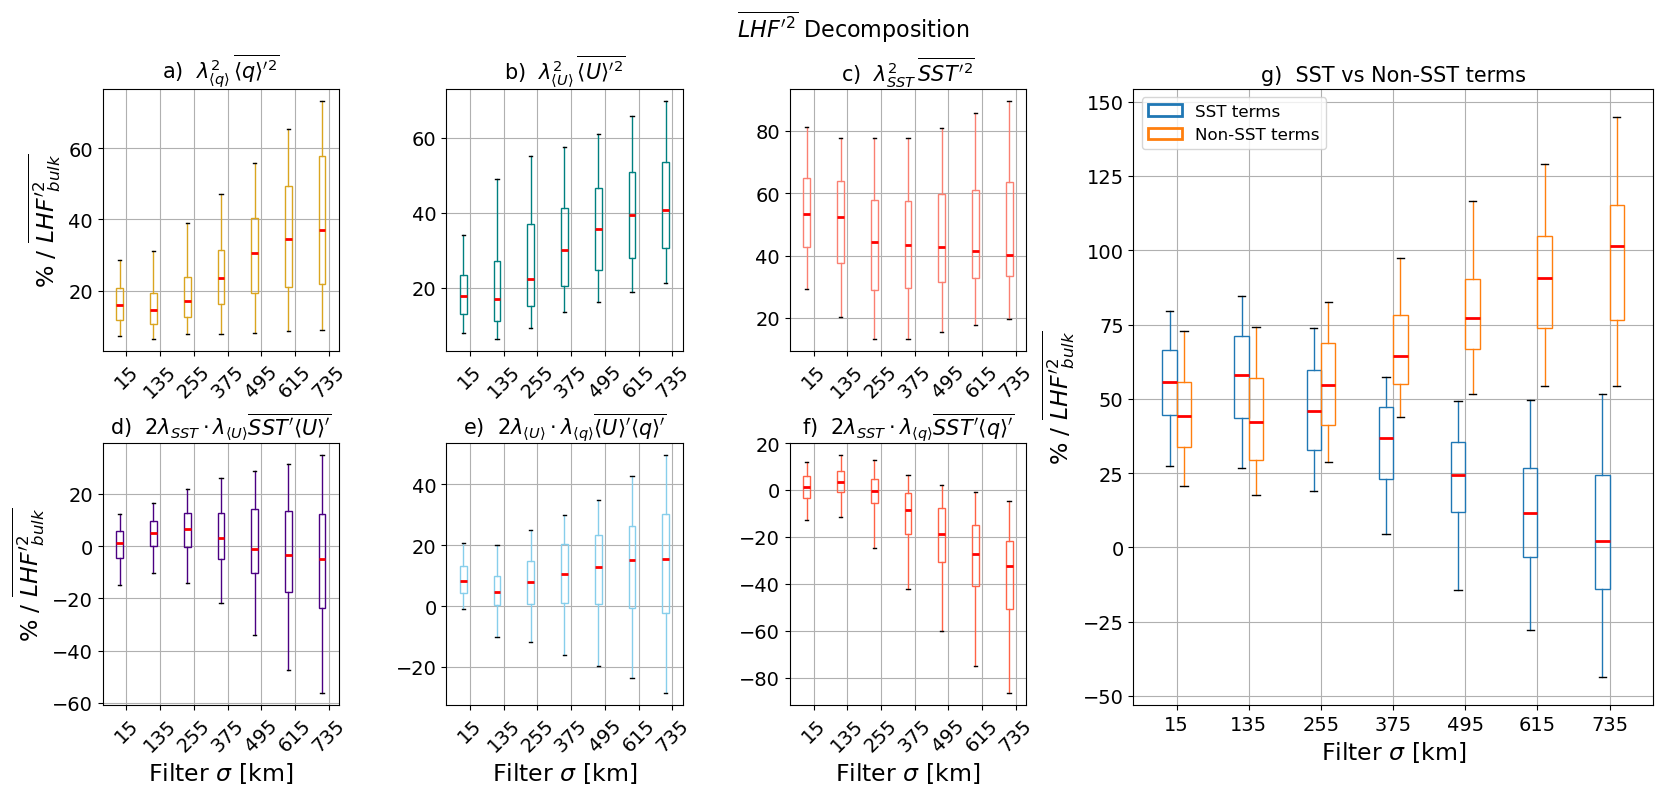

In [87]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# === Create master figure with GridSpec ===
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 2.2], wspace=0.35, hspace=0.35)

# === LEFT: 6 Small Boxplots ===
axs = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]  # 2 rows, 3 columns

# Define parameters
scales_km = [str(3 * j) for j in scales]
colors_lambda = ['#DAA520', '#008080', '#FA8072', '#4B0082', '#87CEEB', '#FF6347']
vars_to_plot = [
    'lambda_var_qa', 'lambda_var_U', 'lambda_var_sst',
    'lambda_covar_U_sst', 'lambda_covar_U_q', 'lambda_covar_q_sst'
]
names_for_vars = [
    r"a)  $\lambda_{\langle q \rangle}^2 \, \overline{\langle q \rangle'^2}$", r"b)  $\lambda_{\langle U \rangle}^2 \, \overline{\langle U \rangle'^2}$", r"c)  $\lambda_{SST}^2 \, \overline{SST'^2}$",
    r"d)  $2 \lambda_{SST}\cdot\lambda_{\langle U \rangle} \overline{SST'\langle U \rangle'}$", r"e)  $2 \lambda_{\langle U \rangle}\cdot\lambda_{\langle q \rangle} \overline{\langle U \rangle'\langle q \rangle'}$", r"f)  $2 \lambda_{SST}\cdot\lambda_{\langle q \rangle} \overline{SST'\langle q \rangle'}$"
]

for i, var in enumerate(vars_to_plot):
    boxplot_local_multiple(
        axs[i], df_var,
        variabs=[var], var_names=[],
        colors=[colors_lambda[i]],
        scales_km=scales_km,
        title=names_for_vars[i],
        axlabs=[r'Filter $\sigma$ [km]', ""]
    )

# Fix axes labels for consistency
axs[0].set_xlabel('')
axs[1].set_xlabel('')
axs[2].set_xlabel('')
axs[0].set_ylabel(r"% / $\overline{LHF'^2_{bulk}}$")
axs[3].set_ylabel(r"% / $\overline{LHF'^2_{bulk}}$")

# === RIGHT: Grouped Boxplot ===
ax_right = fig.add_subplot(gs[:, 3])  # Span both rows in the 4th column

# Plot SST vs non-SST terms
medians_SST = boxplot_local_single_panel(
    ax_right, df_var,
    variabs=['sst_terms'],
    var_names=[r"SST terms"],
    colors=['tab:blue'],
    scales_km=scales_km,
    title=r"SST vs Non-SST terms",
    axlabs=["", r"% wrt $\beta U (q^* - q_{2m})$"],
    group_offset=-0.1
)

medians_nonSST = boxplot_local_single_panel(
    ax_right, df_var,
    variabs=['non-sst_terms'],
    var_names=[r"Non-SST terms"],
    colors=['tab:orange'],
    scales_km=scales_km,
    title=r"g)  SST vs Non-SST terms",
    axlabs=[r"Filter $\sigma$ [km]", r"% / $\overline{LHF'^2_{bulk}}$"],
    group_offset=0.1
)

# Legend
legend_handles = [
    mpatches.Patch(edgecolor='tab:blue', facecolor='none', linewidth=2, label="SST terms"),
    mpatches.Patch(edgecolor='tab:orange', facecolor='none', linewidth=2, label="Non-SST terms")
]
ax_right.legend(handles=legend_handles, loc='best', fontsize=12)

# === Overall title ===
fig.suptitle(r"$\overline{LHF'^2}$ Decomposition", fontsize=16)

# === Save ===
output_path = '/venus/tesi_ale/plots_forced_EU/combined_LHF_variance_boxplots.pdf'
# fig.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved figure to: {output_path}")


## Revised fig. 6 : decompose accounting for coupling coefficients

In [ ]:
sigma_sub = 0 # *3km = 60 km

import pandas as pd

#scales = np.arange(5, 250, 40)
#scales = np.arange(5, 250, 50) # Use the scales that have been previously defined.

scales_km = list(3*scales)
scales_km = [str(i)+' km' for i in scales_km]
dims = sst_ff.shape

variables = ['var_lhf',
            'var_lhf_bulk',
            'var_qa',
            'var_U',
            'covar_U_q',
            'var_sst',
            'covar_U_sst',
            'covar_q_sst',
            'lambda_U',
            'lambda_sst',
            'lambda_q',
            'lambda_var_qa',
            'lambda_var_U',
            'lambda_var_sst',
            'lambda_covar_U_sst',
            'lambda_covar_U_q',
            'lambda_covar_q_sst',
            'sst_terms', 
            'non-sst_terms', 
            'variances', 
            'covariances',
            'lambda_var_q_atm',
            'lambda_var_U_atm',
            'lambda_covar_U_q_atm',
            'lambda_var_sst_atm',
            'lambda_var_sst_u_atm',
            'lambda_var_sst_q_atm',
            'lambda_var_sst_uq_atm',
            'lambda_var_sst_VWM',
            'lambda_covar_sst_q_noatm',
            'lambda_covar_sst_U_noatm',
            'sst_terms_atm',
            'non-sst_terms_atm']

df_var = pd.DataFrame(data=None, index = variables, columns=scales_km)
df_var

In [ ]:
# Get the U and q coupling coeff
slope_u_sst = slopes[2]
slope_q_sst = slopes[3]

# Compute all terms of the variance decomposition
for i,sigma in enumerate(scales):

    # allocate memory for filtered variables
    sst_bar = np.zeros(sst_ff.shape); 
    qa_bar  = np.zeros(qa_ff.shape); 
    U_bar   = np.zeros(U_ff.shape) 
    lhf_bar = np.zeros(dims)
    lhf_bulk_bar = np.zeros(dims)

    sst_prime = np.zeros(sst_ff.shape); 
    qa_prime  = np.zeros(qa_ff.shape); 
    U_prime   = np.zeros(U_ff.shape) 
    lhf_prime = np.zeros(dims)
    lhf_bulk_prime = np.zeros(dims)

    qa_atm  = np.zeros(qa_ff.shape); 
    U_atm   = np.zeros(U_ff.shape) 

    # allocate memory for variances and covariances
    var_U   = np.zeros(dims); 
    var_qa  = np.zeros(dims);
    var_sst = np.zeros(dims); 
    var_lhf = np.zeros(dims);
    var_lhf_bulk = np.zeros(dims)
    var_U_atm   = np.zeros(dims); 
    var_qa_atm  = np.zeros(dims);
    
    covar_U_sst = np.zeros(dims); 
    covar_U_q   = np.zeros(dims); 
    covar_q_sst = np.zeros(dims)
    covar_U_q_atm   = np.zeros(dims); 
    
    for t in range(0,dims[0]):
        sst_bar[t] = functions.nan_gaussian_filter(sst_ff[t],sigma)
        sst_prime[t] = sst_ff[t] - sst_bar[t]

        qa_bar[t] = functions.nan_gaussian_filter(qa_ff[t],sigma) # [kg/kg]
        qa_prime[t] = qa_ff[t] - qa_bar[t] # [kg/kg]
        qa_atm[t] = qa_prime[t] - slope_q_sst[i]*1e-3*sst_prime[t] # [kg/kg]
        
        U_bar[t] = functions.nan_gaussian_filter(U_ff[t],sigma)
        U_prime[t] = U_ff[t] - U_bar[t]
        U_atm[t] = U_prime[t] - slope_u_sst[i]*sst_prime[t] # [m/s]

        lhf_bulk_bar[t] = functions.nan_gaussian_filter(lhf_bulk[t],sigma)
        lhf_bulk_prime[t] = lhf_bulk[t] - lhf_bulk_bar[t]

        """    
        sst_bar[t] = nan_gaussian_filter(sst_ff[t],sigma)
        X_prime = sst_ff[t] - sst_bar[t]
        sst_prime[t] = nan_gaussian_filter(X_prime,sigma_sub)
        
        qa_bar[t] = nan_gaussian_filter(qa_ff[t],sigma)
        X_prime = qa_ff[t] - qa_bar[t]
        qa_prime[t] = nan_gaussian_filter(X_prime,sigma_sub)
        
        U_bar[t] = nan_gaussian_filter(U_ff[t],sigma)
        X_prime = U_ff[t] - U_bar[t]
        U_prime[t] = nan_gaussian_filter(X_prime,sigma_sub)
    
        lhf_bulk_bar[t] = nan_gaussian_filter(lhf_bulk[t],sigma)
        X_prime = lhf_bulk[t] - lhf_bulk_bar[t]
        lhf_bulk_prime[t] = nan_gaussian_filter(X_prime,sigma_sub)
        """

        ## compute variances and covariances
        
        # non sst terms
        var_lhf_bulk[t] = local_variance(lhf_bulk_prime[t], sigma)
        var_qa[t]       = local_variance(qa_prime[t],sigma)
        var_U[t]        = local_variance(U_prime[t],sigma)
        covar_U_q[t]    = local_covariance(U_prime[t],qa_prime[t],sigma)
        var_qa_atm[t]       = local_variance(qa_atm[t],sigma)
        var_U_atm[t]        = local_variance(U_atm[t],sigma)
        covar_U_q_atm[t]    = local_covariance(U_atm[t],qa_atm[t],sigma)
        
        # sst terms
        var_sst[t]     = local_variance(sst_prime[t],sigma)
        covar_U_sst[t] = local_covariance(U_prime[t],sst_prime[t],sigma)
        covar_q_sst[t] = local_covariance(sst_prime[t],qa_prime[t],sigma)

    lambda_U   = beta*(q_sat(sst_bar-273.15,p0)-qa_bar)
    lambda_sst = beta*U_bar*dq_sat_dt(sst_bar-273.15,p0)
    lambda_q   = -beta*U_bar

    # df_var.loc['var_lhf', str(3*sigma)+' km']         = var_lhf.flatten()
    df_var.loc['var_lhf_bulk', str(3*sigma)+' km']    = var_lhf_bulk.flatten()
    df_var.loc['var_qa', str(3*sigma)+' km']          = var_qa.flatten()
    df_var.loc['var_U', str(3*sigma)+' km']           = var_U.flatten()
    df_var.loc['var_sst', str(3*sigma)+' km']         = var_sst.flatten()
    df_var.loc['covar_U_q', str(3*sigma)+' km']       = covar_U_q.flatten()
    df_var.loc['covar_U_sst', str(3*sigma)+' km']     = covar_U_sst.flatten()
    df_var.loc['covar_q_sst', str(3*sigma)+' km']     = covar_q_sst.flatten()
    df_var.loc['lambda_U', str(3*sigma)+' km']        = lambda_U.flatten()
    df_var.loc['lambda_sst', str(3*sigma)+' km']      = lambda_sst.flatten()
    df_var.loc['lambda_q', str(3*sigma)+' km']        = lambda_q.flatten()

    df_var.loc['lambda_var_qa', str(3*sigma)+' km']          = ((lambda_q**2)*var_qa).flatten()
    df_var.loc['lambda_var_U', str(3*sigma)+' km']           = ((lambda_U**2)*var_U).flatten()
    df_var.loc['lambda_var_sst', str(3*sigma)+' km']         = ((lambda_sst**2)*var_sst).flatten()

    df_var.loc['lambda_covar_U_sst', str(3*sigma)+' km']    = (2*lambda_U*lambda_sst*covar_U_sst).flatten()
    df_var.loc['lambda_covar_U_q', str(3*sigma)+' km']      = (2*lambda_U*lambda_q*covar_U_q).flatten()
    df_var.loc['lambda_covar_q_sst', str(3*sigma)+' km']    = (2*lambda_q*lambda_sst*covar_q_sst).flatten()

    df_var.loc['sst_terms', str(3*sigma)+' km']      = (lambda_sst**2*var_sst + 
                                                        2*lambda_sst*(lambda_U*covar_U_sst + 
                                                                      lambda_q*covar_q_sst)).flatten()
    df_var.loc['non-sst_terms', str(3*sigma)+' km']  = (lambda_U**2*var_U + lambda_q**2*var_qa + 
                                                        2*lambda_q*lambda_U*covar_U_q).flatten()
    df_var.loc['variances', str(3*sigma)+' km']      = (lambda_sst**2*var_sst + lambda_U**2*var_U + 
                                                        lambda_q**2*var_qa).flatten()
    df_var.loc['covariances', str(3*sigma)+' km']    = (2*lambda_sst*(lambda_U*covar_U_sst + 
                                                                      lambda_q*covar_q_sst) + 
                                                        2*lambda_q*lambda_U*covar_U_q).flatten()

    df_var.loc['lambda_var_q_atm', str(3*sigma)+' km']           = ((lambda_q**2)*var_qa_atm).flatten()
    df_var.loc['lambda_var_U_atm', str(3*sigma)+' km']           = ((lambda_U**2)*var_U_atm).flatten()
    df_var.loc['lambda_covar_U_q_atm', str(3*sigma)+' km']       = (2*lambda_U*lambda_q*covar_U_q_atm).flatten()
    df_var.loc['lambda_var_sst_atm', str(3*sigma)+' km']         = (lambda_sst**2*var_sst).flatten()
    df_var.loc['lambda_var_sst_u_atm', str(3*sigma)+' km']         = (lambda_U**2*slope_u_sst[i]**2*var_sst).flatten()
    df_var.loc['lambda_var_sst_q_atm', str(3*sigma)+' km']         = (lambda_q**2*slope_q_sst[i]**2*1e-6*var_sst).flatten()
    df_var.loc['lambda_var_sst_uq_atm', str(3*sigma)+' km']         = (2*lambda_U*slope_u_sst[i]*lambda_q*slope_q_sst[i]*1e-3*var_sst).flatten()
    df_var.loc['lambda_covar_sst_U_noatm', str(3*sigma)+' km']       = (2*lambda_sst*lambda_U*slope_u_sst[i]*var_sst).flatten()
    df_var.loc['lambda_covar_sst_q_noatm', str(3*sigma)+' km']       = (2*lambda_sst*lambda_q*slope_q_sst[i]*1e-3*var_sst).flatten()
    
    df_var.loc['sst_terms_atm', str(3*sigma)+' km']         = ((lambda_sst**2+lambda_U**2*slope_u_sst[i]**2+
                                                                lambda_q**2*slope_q_sst[i]**2*1e-6+
                                                                2*lambda_sst*lambda_U*slope_u_sst[i]+
                                                                2*lambda_sst*lambda_q*slope_q_sst[i]*1e-3+
                                                                2*lambda_U*slope_u_sst[i]*lambda_q*slope_q_sst[i]*1e-3)*var_sst).flatten()
    df_var.loc['non-sst_terms_atm', str(3*sigma)+' km'] = ((lambda_q**2)*var_qa_atm + (lambda_U**2)*var_U_atm +
                                                           2*lambda_U*lambda_q*covar_U_q_atm).flatten()

    df_var.loc['lambda_var_sst_VWM', str(3*sigma)+' km'] = (lambda_q**2*slope_q_sst[i]**2*1e-6*var_sst +
                                                            2*lambda_sst*lambda_q*slope_q_sst[i]*1e-3*var_sst).flatten()

            
    print(f"step {i} done")

In [ ]:
## define two slightly different boxplot functions

def boxplot_local_multiple(ax, df, variabs, var_names, colors, scales_km, title, axlabs):
    """
    Plots grouped boxplots for each of the beta_* variables across different filter scales.

    Parameters:
    - ax: matplotlib axis
    - df: pandas DataFrame with variables as rows and filter scales as columns
    - scales_km: list of strings for x-axis tick labels
    - title: plot title
    - axlabs: list [xlabel, ylabel]
    """
    # beta_vars = ['beta_covar_U_Dq', 'beta_Ubar_qprime_bar', 'beta_Uprime_qbar_bar', 'beta_Ubar_qbar_bar']
    # var_names = [r"$\overline{U'\Delta q'}$", r"$\overline{\overline{U} \Delta q'}$", r"$\overline{U'\overline{\Delta q'}}$", r"$\overline{\overline{U} \overline{\Delta q}}$"]
    # colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
    n_groups = len(scales_km)
    n_vars = len(variabs)

    box_data = [[] for _ in range(n_vars)]
    for i, var in enumerate(variabs):
        for col in df.columns:
            arr = 100 * df.loc[var, col] / df.loc['var_lhf_bulk', col]
            arr = arr[~np.isnan(arr)]
            # Trim outliers using 10th and 90th percentiles
            p10, p90 = np.nanpercentile(arr, 10), np.nanpercentile(arr, 90)
            arr = arr[(arr >= p10) & (arr <= p90)]
            box_data[i].append(arr.flatten())

    # Plot grouped boxplots
    positions = []
    width = 0.2
    for i in range(n_vars):
        positions.append(np.arange(n_groups) + (i - 1) * width)
    #positions = scales_km 
    
    for i in range(n_vars):
        bp = ax.boxplot(
            box_data[i], positions=positions[i], widths=width,
            patch_artist=True, showmeans=False, whis=[0, 100],
            boxprops=dict(color=colors[i], facecolor='none'), 
            medianprops=dict(linewidth=2, color='red'),
            whiskerprops=dict(color=colors[i]), 
            #capprops=dict(color=colors[i]),
            flierprops=dict(marker='o', color=colors[i], alpha=0.3)
        )

    ax.set_xticks(np.arange(n_groups))
    ax.set_xticklabels(scales_km, fontsize=14, rotation=45)
    #ax.set_xticks(np.arange(0,3000,500))
    #ax.set_xticklabels(np.arange(0,3000,500), fontsize=14, rotation=45)
    #ax.set_xlim([-75.0, 2895.0])
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(axlabs[0], fontsize=17)
    ax.set_ylabel(axlabs[1], fontsize=17)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True)
    
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(
            edgecolor=colors[i], facecolor='none', linewidth=2, label=var_names[i]
        ) for i in range(len(var_names))
    ]
    
    # ax.legend(handles=legend_handles, loc='upper left', fontsize=12, frameon=True)




def boxplot_local_single_panel(ax, df, variabs, var_names, colors, scales_km, title, axlabs, group_offset=0):
    """
    Plots grouped boxplots for each of the beta_* variables across different filter scales.

    Parameters:
    - ax: matplotlib axis
    - df: pandas DataFrame with variables as rows and filter scales as columns
    - scales_km: list of strings for x-axis tick labels
    - title: plot title
    - axlabs: list [xlabel, ylabel]
    """
    # beta_vars = ['beta_covar_U_Dq', 'beta_Ubar_qprime_bar', 'beta_Uprime_qbar_bar', 'beta_Ubar_qbar_bar']
    # var_names = [r"$\overline{U'\Delta q'}$", r"$\overline{\overline{U} \Delta q'}$", r"$\overline{U'\overline{\Delta q'}}$", r"$\overline{\overline{U} \overline{\Delta q}}$"]
    # colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
    n_groups = len(scales_km)
    n_vars = len(variabs)

    box_data = [[] for _ in range(n_vars)]
    for i, var in enumerate(variabs):
        for col in df.columns:
            arr = 100 * df.loc[var, col] / df.loc['var_lhf_bulk', col]
            arr = arr[~np.isnan(arr)]
            p10, p90 = np.nanpercentile(arr, 10), np.nanpercentile(arr, 90)
            arr = arr[(arr >= p10) & (arr <= p90)]
            box_data[i].append(arr.flatten())

    width = 0.2
    all_medians = {}
    
    for i in range(n_vars):
        positions = np.arange(n_groups) + group_offset + i * width
        bp = ax.boxplot(
            box_data[i], positions=positions, widths=width,
            patch_artist=True, showmeans=False, whis=[0, 100],
            boxprops=dict(color=colors[i], facecolor='none'),
            medianprops=dict(linewidth=2, color='red'),
            whiskerprops=dict(color=colors[i]),
            flierprops=dict(marker='o', color=colors[i], alpha=0.3)
        )
        medians = [line.get_ydata()[0] for line in bp['medians']]
        all_medians[var_names[i]] = medians

    ax.set_xticks(np.arange(n_groups))
    ax.set_xticklabels(scales_km, fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(axlabs[0], fontsize=17)
    ax.set_ylabel(axlabs[1], fontsize=17)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True)
    
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(
            edgecolor=colors[i], facecolor='none', linewidth=2, label=var_names[i]
        ) for i in range(len(var_names))
    ]

    return all_medians
    # ax.legend(handles=legend_handles, loc='best', fontsize=12, frameon=True)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# === Create master figure with GridSpec ===
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 2.2], wspace=0.35, hspace=0.35)

# === LEFT: 6 Small Boxplots ===
axs = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]  # 2 rows, 3 columns

# Define parameters
scales_km = [str(3 * j) for j in scales]
colors_lambda = ['#DAA520', '#008080', '#FA8072', '#4B0082', '#87CEEB', '#FF6347']
vars_to_plot = [
    'lambda_var_qa', 'lambda_var_U', 'lambda_var_sst',
    'lambda_covar_U_sst', 'lambda_covar_U_q', 'lambda_covar_q_sst'
]
names_for_vars = [
    r"a)  $\lambda_{\langle q \rangle}^2 \, \overline{\langle q \rangle'^2}$", r"b)  $\lambda_{\langle U \rangle}^2 \, \overline{\langle U \rangle'^2}$", r"c)  $\lambda_{SST}^2 \, \overline{SST'^2}$",
    r"d)  $2 \lambda_{SST}\cdot\lambda_{\langle U \rangle} \overline{SST'\langle U \rangle'}$", r"e)  $2 \lambda_{\langle U \rangle}\cdot\lambda_{\langle q \rangle} \overline{\langle U \rangle'\langle q \rangle'}$", r"f)  $2 \lambda_{SST}\cdot\lambda_{\langle q \rangle} \overline{SST'\langle q \rangle'}$"
]

for i, var in enumerate(vars_to_plot):
    boxplot_local_multiple(
        axs[i], df_var,
        variabs=[var], var_names=[],
        colors=[colors_lambda[i]],
        scales_km=scales_km,
        title=names_for_vars[i],
        axlabs=[r'Filter scale [km]', ""]
    )

# Fix axes labels for consistency
axs[0].set_xlabel('')
axs[1].set_xlabel('')
axs[2].set_xlabel('')
axs[0].set_ylabel(r"% / $\overline{LHF'^2_{bulk}}$")
axs[3].set_ylabel(r"% / $\overline{LHF'^2_{bulk}}$")

# === RIGHT: Grouped Boxplot ===
ax_right = fig.add_subplot(gs[:, 3])  # Span both rows in the 4th column

# Plot SST vs non-SST terms
medians_SST = boxplot_local_single_panel(
    ax_right, df_var,
    variabs=['sst_terms'],
    var_names=[r"SST terms"],
    colors=['tab:blue'],
    scales_km=scales_km,
    title=r"SST vs Non-SST terms",
    axlabs=["", r"% wrt $\beta U (q^* - q_{2m})$"],
    group_offset=-0.1
)

medians_nonSST = boxplot_local_single_panel(
    ax_right, df_var,
    variabs=['non-sst_terms'],
    var_names=[r"Non-SST terms"],
    colors=['tab:orange'],
    scales_km=scales_km,
    title=r"g)  SST vs Non-SST terms",
    axlabs=[r"Filter scale [km]", r"% / $\overline{LHF'^2_{bulk}}$"],
    group_offset=0.1
)

# Legend
legend_handles = [
    mpatches.Patch(edgecolor='tab:blue', facecolor='none', linewidth=2, label="SST terms"),
    mpatches.Patch(edgecolor='tab:orange', facecolor='none', linewidth=2, label="Non-SST terms")
]
ax_right.legend(handles=legend_handles, loc='best', fontsize=12)

# === Overall title ===
fig.suptitle(r"$\overline{LHF'^2}$ Decomposition", fontsize=16)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# === Create master figure with GridSpec ===
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 2.2], wspace=0.35, hspace=0.35)

# === LEFT: 6 Small Boxplots ===
axs = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]  # 2 rows, 3 columns

# Define parameters
scales_km = [str(4* 3 * j) for j in scales]
colors_lambda = ['#DAA520', '#008080', '#FA8072', '#4B0082', '#87CEEB', '#FF6347']
vars_to_plot = [
    'lambda_var_q_atm', 'lambda_var_U_atm', 'lambda_var_sst',
    'lambda_covar_sst_U_noatm', 'lambda_covar_U_q_atm', 'lambda_var_sst_VWM'
]


names_for_vars = [
    r"a)  $\lambda_{\langle q \rangle}^2 \, \overline{\langle q \rangle_{atm}'^2}$", 
    r"b)  $\lambda_{\langle U \rangle}^2 \, \overline{\langle U \rangle_{atm}'^2}$", 
    r"c)  $\lambda_{SST}^2\, \overline{SST'^2}$",
    r"d)  $2 \alpha_{\langle U \rangle}\, \lambda_{SST}\, \lambda_{\langle U \rangle}\, \overline{SST'^2}$", 
    r"e)  $2 \lambda_{\langle U \rangle}\,\lambda_{\langle q \rangle} \overline{\langle U \rangle_{atm}'\langle q \rangle_{atm}'}$", 
    r"f)  $\alpha_{\langle q \rangle}\,\lambda_{\langle q \rangle}(\alpha_{\langle q \rangle}\,\lambda_{\langle q \rangle}+2\lambda_{SST})\, \overline{SST'^2}$"
]

for i, var in enumerate(vars_to_plot):
    boxplot_local_multiple(
        axs[i], df_var,
        variabs=[var], var_names=[],
        colors=[colors_lambda[i]],
        scales_km=scales_km,
        title=names_for_vars[i],
        axlabs=[r'Filter scale, $L$ / km', ""]
    )

# Fix axes labels for consistency
axs[0].set_xlabel('')
axs[1].set_xlabel('')
axs[2].set_xlabel('')
axs[0].set_ylabel("")
axs[3].set_ylabel("")

# === RIGHT: Grouped Boxplot ===
ax_right = fig.add_subplot(gs[:, 3])  # Span both rows in the 4th column

# Plot SST vs non-SST terms
medians_SST = boxplot_local_single_panel(
    ax_right, df_var,
    variabs=['sst_terms_atm'],
    var_names=[r"SST terms"],
    colors=['tab:blue'],
    scales_km=scales_km,
    title=r"SST vs Non-SST terms",
    axlabs=["", r"% wrt $\beta U (q^* - q_{2m})$"],
    group_offset=-0.1
)

medians_nonSST = boxplot_local_single_panel(
    ax_right, df_var,
    variabs=['non-sst_terms_atm'],
    var_names=[r"Non-SST terms"],
    colors=['tab:orange'],
    scales_km=scales_km,
    title=r"g)  SST vs Non-SST terms",
    axlabs=[r"Filter scale, $L$ / km", ""],
    group_offset=0.1
)

# Legend
legend_handles = [
    mpatches.Patch(edgecolor='tab:blue', facecolor='none', linewidth=2, label="SST terms"),
    mpatches.Patch(edgecolor='tab:orange', facecolor='none', linewidth=2, label="Non-SST terms")
]
ax_right.legend(handles=legend_handles, loc='best', fontsize=12)

# === Overall title ===
fig.suptitle(r"Percentage $\overline{LHF'^2}$ decomposition", fontsize=16)